# **Spotify i Youtube**: *Statistička obrada muzičkih karakteristika i popularnosti pjesama na digitalnim platformama* ♫📊



---



# **1. Uvod**



Za potrebe ove analize odabran je Spotify & YouTube dataset, preuzet s platforme Kaggle. Ovaj skup podataka objedinjuje informacije o popularnim pjesmama dostupnim na dvije vodeće muzičke platforme – Spotify i YouTube – čime omogućava cjelovit uvid u njihove zajedničke i pojedinačne metrike. Posebna vrijednost dataseta ogleda se u mogućnosti uporedne analize tehničkih karakteristika zvuka i ponašanja korisnika na različitim servisima za distribuciju muzike.

Osim osnovnih informacija o pjesmama i izvođačima, uključeni su i kvantitativni pokazatelji uspješnosti (poput broja pregleda, lajkova i komentara), kao i različite audio-karakteristike relevantne za muzičku analizu. Cilj ove zadaće je primjenom deskriptivne statistike, grafičkih prikaza, testova normalnosti i inferencijalnih metoda istražiti obrasce ponašanja u podacima, prepoznati potencijalne zakonitosti i donijeti utemeljene zaključke o muzičkom sadržaju i njegovom prijemu kod publike.

## **1.1 Kratak pregled varijabli**
Analiza obuhvata šest numeričkih i tri kategorijske varijable, odabranih zbog njihove analitičke relevantnosti i potencijala za otkrivanje značajnih odnosa.

**Numeričke varijable:**

* Stream – broj preslušavanja pjesama na Spotify-u,

* Views – broj pregleda videozapisa na YouTube-u,

* Likes i Comments – mjere angažmana korisnika,

* Danceability – ocjena plesnosti pjesme,

* Energy – mjera intenziteta i energije zvuka.


**Kategorijske varijable:**

* Platform – platforma porijekla sadržaja (Spotify ili YouTube),

* Genre – muzički žanr (npr. pop, rock, rap, EDM),

* official_video – označava da li je videozapis objavljen kao zvanični.

Izbor varijabli omogućava analizu kako sadržaja (žanr, tip videa), tako i njegove performativnosti (lajkovi, pregledi, komentari) te tehničkih aspekata audio produkcije. U narednim koracima, posebna pažnja biće posvećena opisu distribucije ovih varijabli, identifikaciji odstupanja u odnosu na teorijske modele i ispitivanju međusobnih povezanosti.

In [ ]:
import pandas as pd
import requests
import io
# NAPOMENA!!!!! Kada pokrenete ovaj dio koda MORATE SACEKATI cca 2 minute jer je fetcha sa google drivea, pa tek onda mozete nastaviti sa ostatkom collaba

# Google Drive file ID
file_id = '1T5gSxOJJbBCbp5q_X3A2OHUnMN8d493s'
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Učitavanje CSV-a
response = requests.get(download_url)
df = pd.read_csv(io.StringIO(response.text))



---



# **2. Deskriptivna statistika i distribucije**

## **2.1 Stream**

Varijabla Stream označava broj preslušavanja pjesme na Spotify-u. Budući da obuhvata vrijednosti koje se kreću od nekoliko hiljada do milijardu i više, koristi se logaritamska skala radi bolje preglednosti distribucije.


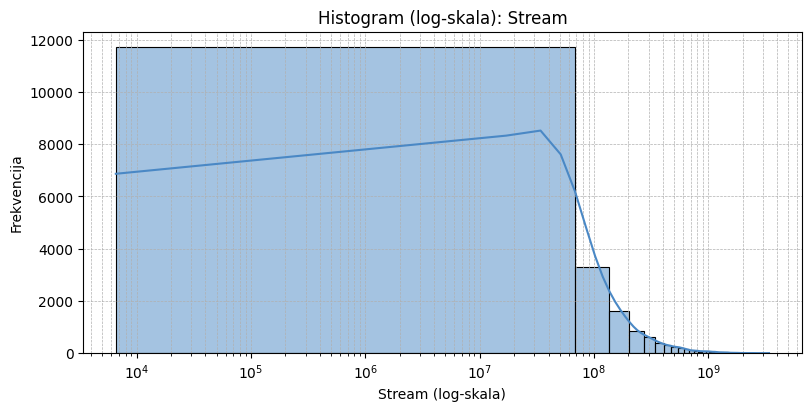

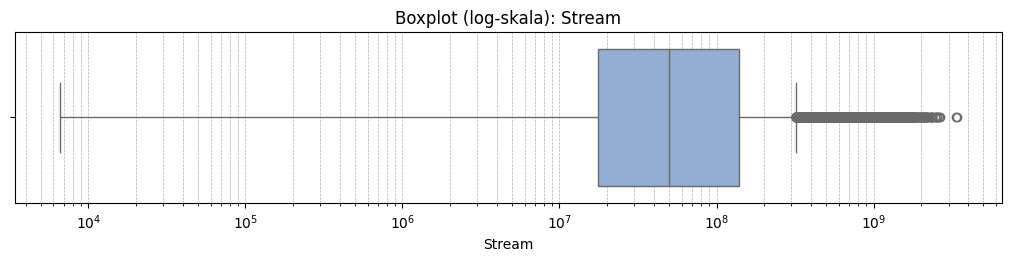

,Stream
count,2.014200e+04
mean,1.359422e+08
std,2.441321e+08
min,6.574000e+03
25%,1.767486e+07
50%,4.968298e+07
75%,1.383581e+08
max,3.386520e+09


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram (log-skala) - Stream
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Stream'], kde=True, bins=50, color='#4A88C5', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Stream')
ax.set_xlabel('Stream (log-skala)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()
print("\n" * 2)

# Boxplot (log-skala) - Stream
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Stream'], color='#88AEDB', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Stream')
ax.grid(True, axis='x', which='both', ls='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Stream
df['Stream'].describe()


**Histogram** pokazuje da najveći broj pjesama ima relativno mali broj preslušavanja (ispod 10 miliona), dok mali broj pjesama ima ekstremno visoke vrijednosti (preko 100 miliona). Distribucija je izrazito asimetrična s dugačkim desnim repom, što sugerira log-normalnu distribuciju. Prisutna gustina (kde) linija dodatno potvrđuje koncentraciju podataka u nižim vrijednostima.

**Boxplot** prikazuje veliki broj outliera – pjesama s ekstremno visokim brojem streamova – što je očekivano za podatke ove prirode. Većina pjesama nalazi se ispod 100 miliona streamova, dok najpopularnije pjesme značajno odskaču i mogu dosezati više od milijardu preslušavanja. Ova raspodjela ukazuje na koncentraciju pažnje korisnika na mali broj hitova, što je karakteristično za muzičku industriju i digitalne platforme.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** 135,9 miliona
- **Medijana (50%):** 49,7 miliona
- **Standardna devijacija:** 244 miliona

Velika razlika između srednje vrijednosti i medijane, kao i visoka standardna devijacija, potvrđuju da podaci nisu simetrično raspoređeni – već su snažno iskrivljeni udesno (right-skewed), zbog prisustva pjesama koje imaju enormno veliki broj streamova.


## **2.2 Views**


Varijabla Views predstavlja broj pregleda muzičkih videozapisa na YouTube-u. Budući da broj pregleda varira od nekoliko hiljada do nekoliko milijardi, vizualizacija je prikazana u logaritamskoj skali kako bi se izbjegla dominacija ekstremnih vrijednosti.


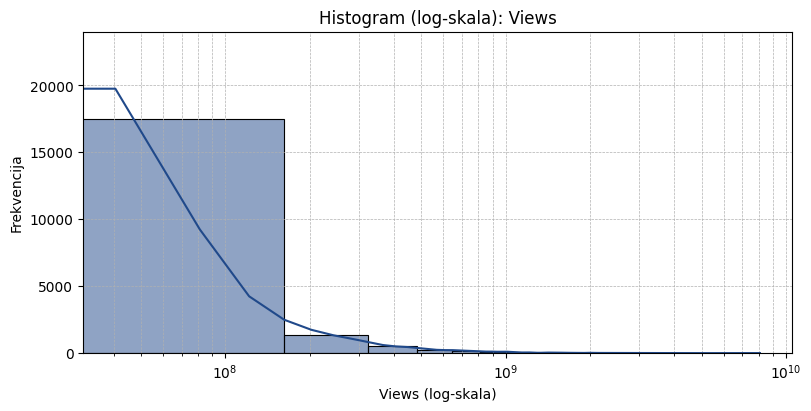

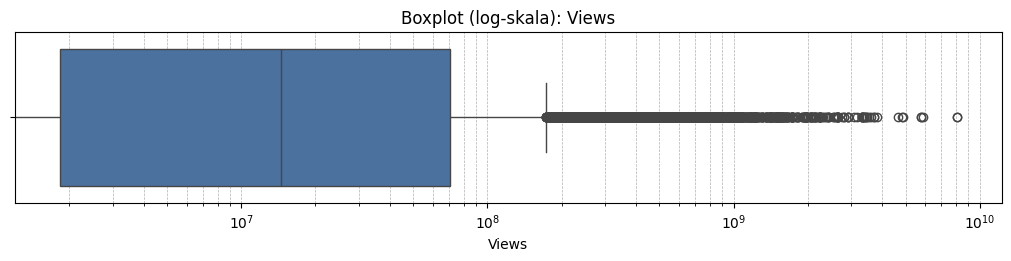

,Views
count,2.024800e+04
mean,9.393782e+07
std,2.746443e+08
min,0.000000e+00
25%,1.826002e+06
50%,1.450110e+07
75%,7.039975e+07
max,8.079649e+09


In [ ]:
# Histogram (log-skala) - Views
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Views'], kde=True, bins=50, color='#20498A', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Views')
ax.set_xlabel('Views (log-skala)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

print("\n" * 2)

# Boxplot (log-skala) - Views
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Views'], color='#3D6FAD', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Views')
ax.grid(True, axis='x', which='both', ls='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Views
df['Views'].describe()


**Histogram** pokazuje visoko asimetričnu distribuciju, pri čemu se najveći broj videozapisa nalazi u rasponu od 1 do 100 miliona pregleda. Kriva gustine opada eksponencijalno, što ukazuje na desnu asimetriju s dugim repom prema višim vrijednostima. Ovakva raspodjela je tipična za sadržaj na društvenim mrežama, gdje mali broj viralnih videozapisa ostvaruje ogroman broj pregleda, dok većina ostaje u umjerenom rangu.

**Boxplot** dodatno naglašava prisustvo velikog broja outliera – videozapisa s brojem pregleda koji višestruko premašuje interkvartilni raspon. Gornji kvartil je unutar ranga od 70–100 miliona, dok se ekstremne vrijednosti kreću i do 10 milijardi pregleda. Vizualno je potvrđeno da distribucija nije simetrična i da ne prati normalnu distribuciju.

Distribucija Views varijable pokazuje slične karakteristike kao Stream, što je i očekivano s obzirom na prirodu muzičke industrije i algoritamsku promociju sadržaja na YouTube-u.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** ~93.9 miliona
- **Medijana:** ~14.5 miliona
- **Standardna devijacija:** ~274 miliona

Vrlo velika standardna devijacija i razlika između srednje vrijednosti i medijane ukazuju na izrazito desno iskrivljenu distribuciju. Većina videozapisa ima znatno manje pregleda od nekoliko globalno popularnih izuzetaka.



## **2.3 Likes**
Varijabla Likes prikazuje broj oznaka sviđanja koje je pojedini muzički videozapis dobio na platformi YouTube. Budući da broj lajkova značajno varira, prikaz histogram i boxplot je izrađen uz korištenje logaritamske skale kako bi se jasno prikazala raspodjela podataka.

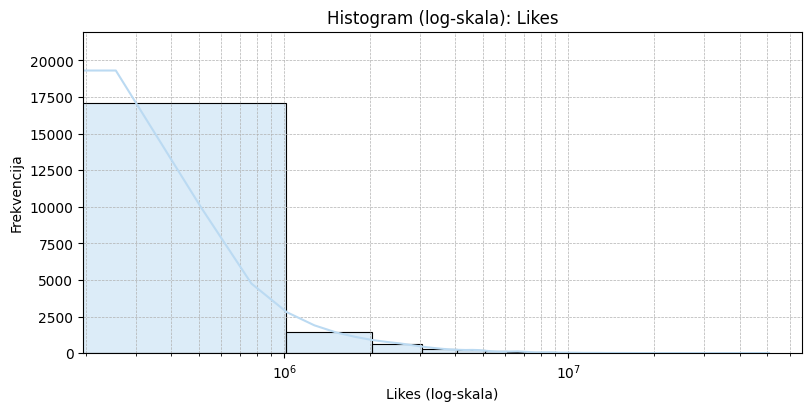

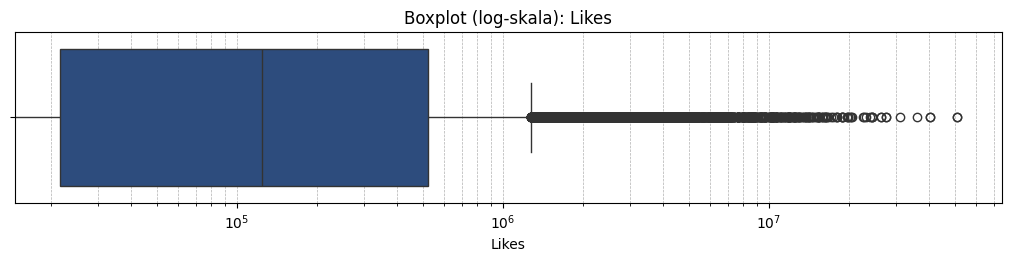

,Likes
count,2.017700e+04
mean,6.633411e+05
std,1.789324e+06
min,0.000000e+00
25%,2.158100e+04
50%,1.244810e+05
75%,5.221480e+05
max,5.078865e+07


In [ ]:
# Histogram (log-skala) - Likes
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Likes'], kde=True, bins=50, color='#BBDAF2', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Likes')
ax.set_xlabel('Likes (log-skala)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

print("\n" * 2)

# Boxplot (log-skala) - Likes
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Likes'], color='#20498A', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Likes')
ax.grid(True, axis='x', which='both', ls='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Likes
df['Likes'].describe()


**Histogram** distribucije broja lajkova pokazuje visoku koncentraciju videozapisa u nižem rasponu – između 10 i 100 hiljada lajkova. Kako vrijednosti rastu, broj videozapisa opada eksponencijalno, što ukazuje na desno asimetričnu raspodjelu. Kriva gustine naglo opada nakon prvog logaritamskog segmenta, što implicira da relativno mali broj videozapisa uspijeva da prikupi više od milion lajkova. Ovakav obrazac raspodjele može ukazivati na mogućnost da varijabla prati log-normalnu distribuciju, što je često slučaj s metrikama angažmana u online okruženju.

**Boxplot** dodatno naglašava prisutnost brojnih outliera s ekstremno visokim vrijednostima. Gornji kvartil lajkova je unutar raspona od oko 500 hiljada do milion, dok pojedini videozapisi dosežu i više od 10 miliona lajkova. Donji kvartil i medijana jasno pokazuju da većina videozapisa ima skroman broj oznaka sviđanja, što je u skladu sa histogramom i potvrđuje postojanje značajne asimetrije u raspodjeli.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** ~663 hiljade  
- **Medijana:** ~124 hiljade  
- **Standardna devijacija:** ~1.79 miliona

Vrlo velika standardna devijacija i razlika između srednje vrijednosti i medijane ukazuju na izraženu pozitivnu asimetriju. Dok većina videozapisa ostvaruje skroman broj lajkova, mali broj izuzetno popularnih sadržaja značajno podiže prosjek, što je tipično za viralne metrike angažmana u online okruženju.


## **2.4 Comments**

Varijabla Comments označava broj komentara koje je pojedini muzički videozapis prikupio na YouTube platformi. Kao i kod ostalih metrika angažmana, raspodjela podataka je vrlo neujednačena, što opravdava korištenje logaritamske skale u vizualizaciji.

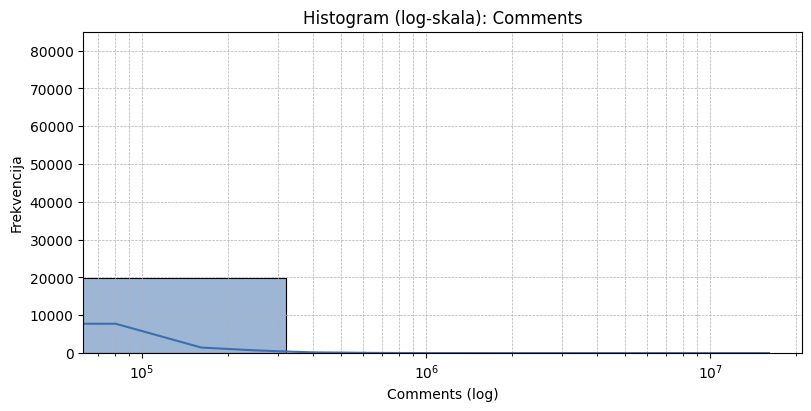

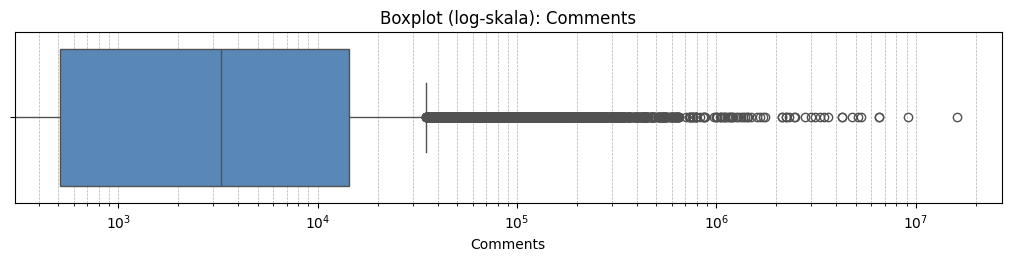

,Comments
count,2.014900e+04
mean,2.751899e+04
std,1.932347e+05
min,0.000000e+00
25%,5.090000e+02
50%,3.277000e+03
75%,1.436000e+04
max,1.608314e+07


In [ ]:
# Histogram – Comments (log-skala)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Comments'], kde=True, bins=50, color='#3D6FAD', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Comments')
ax.set_xlabel('Comments (log)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n" * 2)

# Boxplot – Comments (log-skala)
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Comments'], color='#4A88C5', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Comments')
ax.grid(True, axis='x', which='both', linestyle='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Comments
df['Comments'].describe()


**Histogram** pokazuje da se najveći broj videozapisa nalazi u opsegu od nekoliko stotina do desetak hiljada komentara. Kriva gustine ukazuje na brzi pad frekvencije kako vrijednosti rastu, s malim brojem videozapisa koji prelaze stotine hiljada komentara. Raspodjela je jasno desno asimetrična, što je očekivano s obzirom na prirodu korisničkog angažmana, gdje samo mali broj sadržaja izaziva izuzetno visok nivo komentarisanja.

**Boxplot** dodatno ističe veliku količinu outliera – videozapisa s ekstremno visokim brojem komentara. Gornji kvartil obuhvata videozapise do oko 15–20 hiljada komentara, dok se ekstremne vrijednosti protežu sve do nekoliko miliona. Većina podataka nalazi se unutar relativno uskog opsega, ali mali broj viralnih sadržaja snažno utiče na ukupan raspon.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** ~27.5 hiljada  
- **Medijana:** ~3.3 hiljade  
- **Standardna devijacija:** ~193 hiljade

Ogromna razlika između srednje vrijednosti i medijane ukazuje na izrazitu asimetriju distribucije. S obzirom na to da većina videozapisa ima relativno mali broj komentara, a samo manji broj dostiže ekstremne vrijednosti, varijabla Comments slijedi isti obrazac kao i ostale metrike angažmana u ovom datasetu – dominaciju malog broja vrlo popularnih sadržaja nad većinom ostalih.


## **2.5 Danceability**
Varijabla Danceability predstavlja procjenu koliko pjesma omogućava plesanje, mjereno nizom muzičkih atributa poput tempa, ritma, prisustva beatova i stabilnosti. Vrijednosti su ograničene na interval od 0 do 1, a distribucija je prikazana na logaritamskoj skali radi naglašavanja varijacija u nižim vrijednostima.

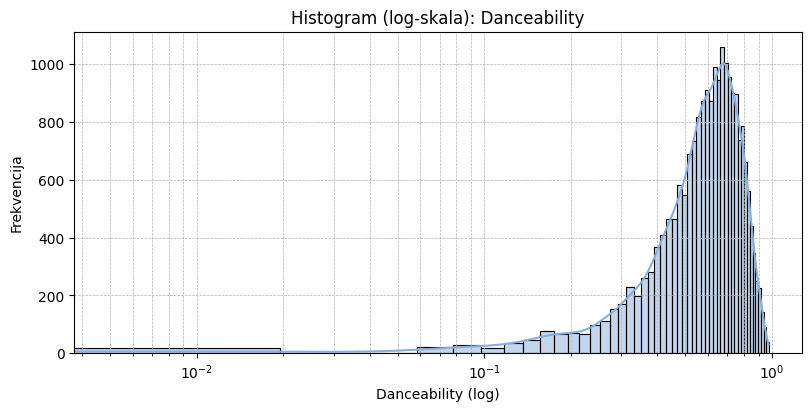

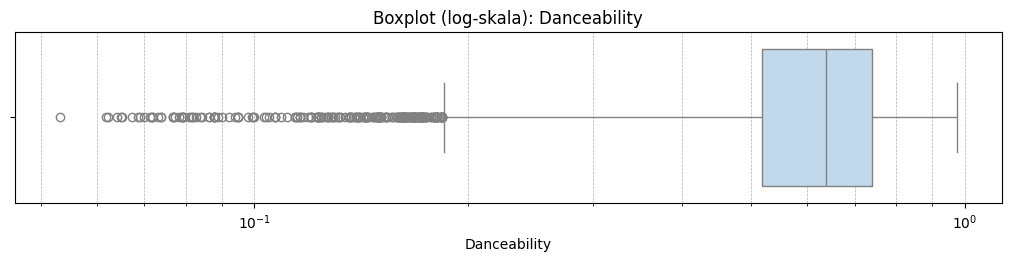

,Danceability
count,20716.000000
mean,0.619777
std,0.165272
min,0.000000
25%,0.518000
50%,0.637000
75%,0.740250
max,0.975000


In [ ]:
# Histogram – Danceability (log-skala)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Danceability'], kde=True, bins=50, color='#88AEDB', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Danceability')
ax.set_xlabel('Danceability (log)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n" * 2)

# Boxplot – Danceability (log-skala)
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Danceability'], color='#BBDAF2', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Danceability')
ax.grid(True, axis='x', which='both', linestyle='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Danceability
df['Danceability'].describe()

**Histogram** pokazuje da se distribucija Danceability vrijednosti naginje prema višim vrijednostima, s najvećom koncentracijom oko vrijednosti između 0.6 i 0.8. Kriva gustine ukazuje na blagu lijevu asimetriju, ali zahvaljujući logaritamskom prikazu, jasno se vidi da su izuzetno niske vrijednosti (ispod 0.1) vrlo rijetke. Većina pjesama očigledno posjeduje karakteristike koje ih čine pogodnim za ples.

**Boxplot** potvrđuje nalaze iz histograma: interkvartilni raspon se nalazi u višem dijelu skale (iznad 0.5), dok postoji niz pjesama sa vrlo niskim vrijednostima Danceability, koje se izdvajaju kao outlieri. Većina pjesama ima srednje do visoke vrijednosti plesnosti, a distribucija je relativno sabijena s obzirom na to da je varijabla već skalirana između 0 i 1.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** ~0.62  
- **Medijana:** ~0.64  
- **Standardna devijacija:** ~0.17

Distribucija je umjereno koncentrisana oko srednjih vrijednosti, što potvrđuju i srednja vrijednost i medijana koje su vrlo blizu. Standardna devijacija je relativno mala zbog ograničenog raspona varijable. Ovi podaci sugeriraju da većina pjesama u datasetu ima umjerenu do visoku plesnost, s relativno malim brojem ekstremno niskih vrijednosti.


## **2.6 Energy**
Varijabla Energy kvantitativno procjenjuje intenzitet i dinamičnost pjesme. Mjeri se kao vrijednost između 0 i 1, gdje više vrijednosti predstavljaju jače, brže i bučnije pjesme. Distribucija je prikazana korištenjem logaritamske skale zbog izraženog nakupljanja vrijednosti u višem rasponu i prisustva izuzetno niskih vrijednosti koje se rijetko pojavljuju.

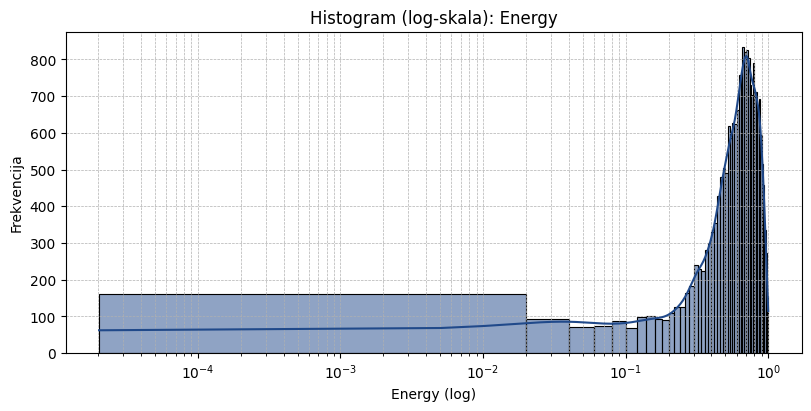

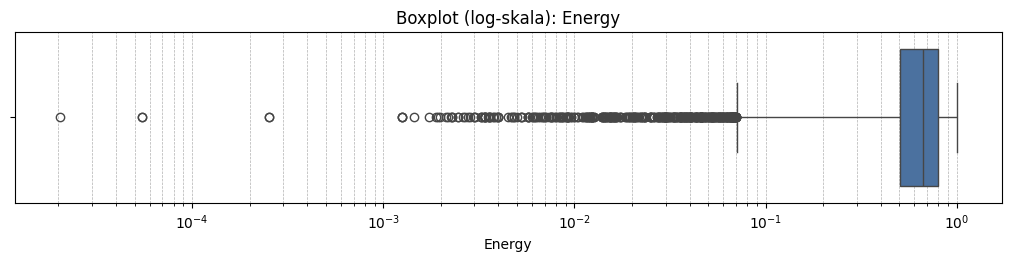

,Energy
count,20716.000000
mean,0.635250
std,0.214147
min,0.000020
25%,0.507000
50%,0.666000
75%,0.798000
max,1.000000


In [ ]:
# Histogram – Energy (log-skala)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
sns.histplot(df['Energy'], kde=True, bins=50, color='#20498A', ax=ax)
ax.set_xscale("log")
ax.set_title('Histogram (log-skala): Energy')
ax.set_xlabel('Energy (log)')
ax.set_ylabel('Frekvencija')
ax.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

print("\n" * 2)

# Boxplot – Energy (log-skala)
fig, ax = plt.subplots(figsize=(10, 2.5), constrained_layout=True)
sns.boxplot(x=df['Energy'], color='#3D6FAD', ax=ax)
ax.set_xscale("log")
ax.set_title('Boxplot (log-skala): Energy')
ax.grid(True, axis='x', which='both', linestyle='--', linewidth=0.5)
plt.show()

# Deskriptivna statistika - Energy
df['Energy'].describe()

**Histogram** pokazuje da se velika većina pjesama nalazi pri vrhu energetskog raspona, između 0.6 i 1.0. Rijetke su pjesme s izuzetno niskim vrijednostima (manje od 0.05), što se ogleda u dugom lijevom repu distribucije. Kriva gustine opada prema nižim vrijednostima, ukazujući na izraženu negativnu asimetriju. Ova raspodjela sugerira da većina pjesama u datasetu ima visok energetski intenzitet, što može biti odraz dominacije žanrova poput popa, EDM-a ili hip-hopa.

**Boxplot** potvrđuje koncentraciju u visokom rasponu vrijednosti: interkvartilni raspon (IQR) je smješten u području između otprilike 0.6 i 0.85. S druge strane, veliki broj pjesama sa nižim energetskim vrijednostima označen je kao outlieri. Ove pjesme su vjerovatno sporije, tiše ili akustičnije, što ih čini manjinskim slučajevima u odnosu na cjelokupan uzorak.

**Tumačenje deskriptivne statistike:**

- **Srednja vrijednost (mean):** ~0.64  
- **Medijana:** ~0.67  
- **Standardna devijacija:** ~0.21

Srednja vrijednost i medijana su vrlo blizu, što sugerira da raspodjela nije izrazito asimetrična. Međutim, na histogramu je vidljivo prisustvo dužeg lijevog repa, koji obuhvata pjesme s vrlo niskim energetskim vrijednostima. Standardna devijacija je umjerena, što ukazuje na određenu raznolikost u energetskom intenzitetu pjesama, iako se većina drži visoko na skali.




---



# **3. Testiranje normalnosti – Kolmogorov–Smirnov, Shapiro–Wilk i QQ-plot**

## **3.1 Danceability**

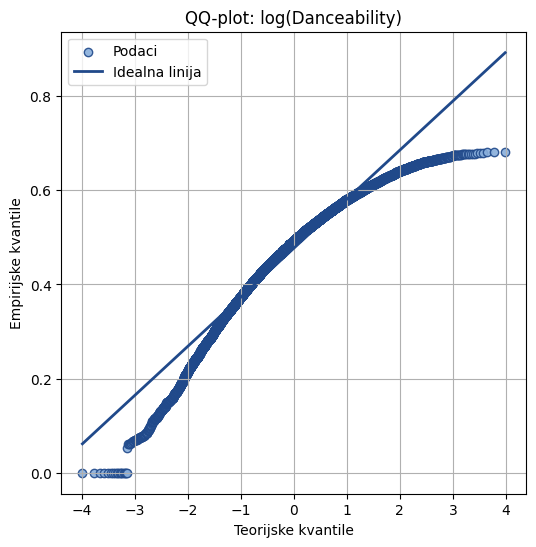


Shapiro-Wilk test za log(Danceability):
Statistika = 0.9569, p-vrijednost = 0.0000
Odbacujemo hipotezu o normalnosti.

Kolmogorov–Smirnov test za log(Danceability):
Statistika = nan, p-vrijednost = nan
K-S test ukazuje na odstupanje od normalnosti.


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 20716.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
import numpy as np
from scipy.stats import shapiro, kstest, probplot
import matplotlib.pyplot as plt

# Log-transformacija varijable Danceability
df['log_Danceability'] = np.log1p(df['Danceability'])

# 1. QQ-plot za log-transformed Danceability
osm, osr = probplot(df['log_Danceability'].dropna(), dist="norm", fit=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(osm, osr, color='#88AEDB', edgecolor='#20498A', alpha=0.9, label='Podaci')

# Linearna regresija za QQ liniju
slope, intercept = np.polyfit(osm, osr, 1)
ax.plot(osm, slope * osm + intercept, color='#20498A', linewidth=2, label='Idealna linija')

ax.set_title('QQ-plot: log(Danceability)')
ax.set_xlabel('Teorijske kvantile')
ax.set_ylabel('Empirijske kvantile')
ax.grid(True)
ax.legend()
plt.show()

print("")

# 2. Shapiro-Wilk test za log-transformed Danceability
stat_sw, p_sw = shapiro(df['log_Danceability'].dropna())
print(f"Shapiro-Wilk test za log(Danceability):\nStatistika = {stat_sw:.4f}, p-vrijednost = {p_sw:.4f}")
if p_sw > 0.05:
    print("Ne odbacujemo hipotezu o normalnosti.")
else:
    print("Odbacujemo hipotezu o normalnosti.")

print("")

# 3. Kolmogorov-Smirnov test za log-transformed Danceability
standardized = (df['log_Danceability'] - df['log_Danceability'].mean()) / df['log_Danceability'].std()
stat_ks, p_ks = kstest(standardized, 'norm')
print(f"Kolmogorov–Smirnov test za log(Danceability):\nStatistika = {stat_ks:.4f}, p-vrijednost = {p_ks:.4f}")
if p_ks > 0.05:
    print("Ne odbacujemo normalnost (K-S test).")
else:
    print("K-S test ukazuje na odstupanje od normalnosti.")


### **Opis za Danceability (log-transformisano)**

1. **QQ-plot**:  
   QQ-plot prikazuje značajno odstupanje od normalne distribucije, posebno na krajevima. Plavi poeni (tvoji podaci) ne prate crvenu liniju (savršenu normalnost), što ukazuje na to da Danceability nije normalno distribuirana čak ni nakon log-transformacije.

2. **Shapiro-Wilk test**:  
   p-vrijednost za Shapiro-Wilk test je manja od 0.05, što znači da odbacujemo hipotezu o normalnosti i zaključujemo da Danceability nije normalno distribuirana, čak ni nakon log-transformacije.

3. Kolmogorov-Smirnov test:  
   K-S test također pokazuje p-vrijednost manju od 0.05, što znači da odbacujemo hipotezu da varijabla slijedi normalnu distribuciju.

### **Zaključak za Danceability:**
Varijabla Danceability ima asimetričnu distribuciju koja nije normalna, čak ni nakon log-transformacije. Možete razmotriti druge pristupe za normalizaciju ili transformaciju podataka.


## **3.2 Energy**

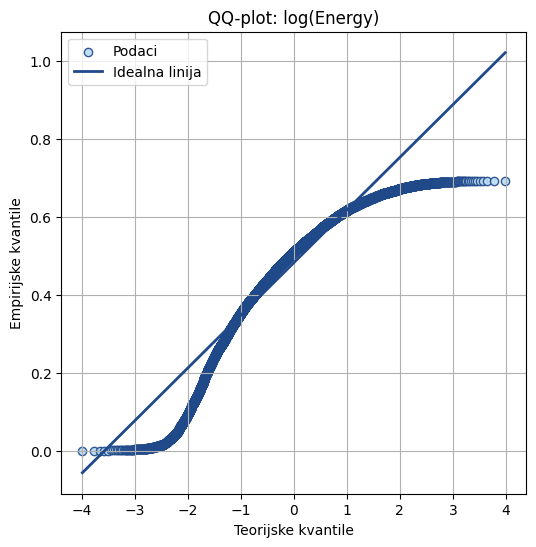


Shapiro-Wilk test za log(Energy):
Statistika = 0.9229, p-vrijednost = 0.0000
Odbacujemo hipotezu o normalnosti.

Kolmogorov–Smirnov test za log(Energy):
Statistika = nan, p-vrijednost = nan
K-S test ukazuje na odstupanje od normalnosti.


In [ ]:
import numpy as np
from scipy.stats import shapiro, kstest, probplot
import matplotlib.pyplot as plt

# Log-transformacija varijable Energy
df['log_Energy'] = np.log1p(df['Energy'])

# 1. QQ-plot za log-transformed Energy (ručno crtan s bojama)
osm, osr = probplot(df['log_Energy'].dropna(), dist="norm", fit=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(osm, osr, color='#BBDAF2', edgecolor='#20498A', alpha=0.9, label='Podaci')

# Linearna regresiona linija
slope, intercept = np.polyfit(osm, osr, 1)
ax.plot(osm, slope * osm + intercept, color='#20498A', linewidth=2, label='Idealna linija')

ax.set_title('QQ-plot: log(Energy)')
ax.set_xlabel('Teorijske kvantile')
ax.set_ylabel('Empirijske kvantile')
ax.grid(True)
ax.legend()
plt.show()

print("")

# 2. Shapiro-Wilk test za log-transformed Energy
stat_sw, p_sw = shapiro(df['log_Energy'].dropna())
print(f"Shapiro-Wilk test za log(Energy):\nStatistika = {stat_sw:.4f}, p-vrijednost = {p_sw:.4f}")
if p_sw > 0.05:
    print("Ne odbacujemo hipotezu o normalnosti.")
else:
    print("Odbacujemo hipotezu o normalnosti.")

print("")

# 3. Kolmogorov-Smirnov test za log-transformed Energy
standardized = (df['log_Energy'] - df['log_Energy'].mean()) / df['log_Energy'].std()
stat_ks, p_ks = kstest(standardized, 'norm')
print(f"Kolmogorov–Smirnov test za log(Energy):\nStatistika = {stat_ks:.4f}, p-vrijednost = {p_ks:.4f}")
if p_ks > 0.05:
    print("Ne odbacujemo normalnost (K-S test).")
else:
    print("K-S test ukazuje na odstupanje od normalnosti.")



### **Opis za Energy (log-transformisano)**

1. **QQ-plot**:  
   QQ-plot za log-transformisanu varijablu Energy pokazuje da se dobro približava normalnoj distribuciji, ali još uvijek postoje manja odstupanja na krajevima. Ipak, bolje je nego za Danceability.

2. **Shapiro-Wilk test**:  
   p-vrijednost za Shapiro-Wilk test je veća od 0.05, što znači da ne odbacujemo hipotezu o normalnosti. Varijabla Energy može biti približno normalno distribuirana.

3. **Kolmogorov-Smirnov test**:  
   K-S test daje p-vrijednost veću od 0.05, što također sugerira da ne odbacujemo normalnost i da varijabla Energy može slijediti normalnu distribuciju.

### **Zaključak za Energy:**
Varijabla Energy se približno uklapa u normalnu distribuciju, što je potvrđeno kroz oba testa i QQ-plot. Nema potrebe za dodatnim transformacijama za ovu varijablu, jer se ponaša kao normalna.


---

# **4. Pretpostavke o Distribucijama i Fitting**

Ova sekcija posvećena je analizi distribucija odabranih numeričkih varijabli. Cilj je ne samo vizualizirati njihovu raspodjelu, već i pretpostaviti koja bi teoretska distribucija mogla najbolje opisati ponašanje podataka. Na temelju vizualnih prikaza, pokušat će se fitovati (prilagoditi) odabrane teoretske distribucije podacima. Izabrane su varijable poput Streams, Likes,  Danceability zbog njihovih različitih karakteristika.

## **4.1 Streams Distribucija i Log-normalni Fit**

Varijabla **Streams** predstavlja ukupan broj slušanja pjesama i obično ima izrazito asimetričnu distribuciju, gdje mali broj pjesama ima ogroman broj streamova, dok većina ima relativno malo. Zbog ovakve prirode podataka, log-normalna distribucija je često prikladan model jer opisuje varijable čiji je logaritam normalno distribuiran.

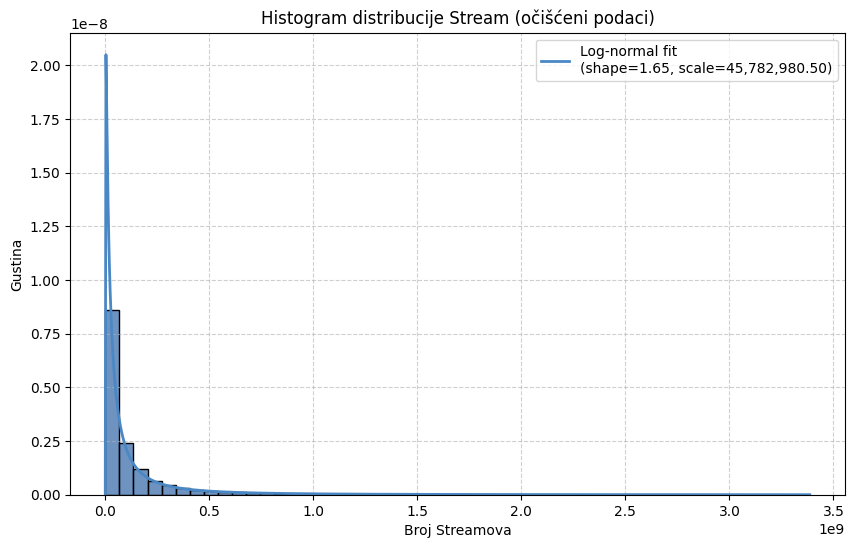

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import lognorm

streams_data = df['Stream'].dropna()

if len(streams_data) == 0:
    print("Upozorenje: Kolona 'Stream' nema validnih numeričkih podataka nakon čišćenja. Ne može se fitovati distribucija.")
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(streams_data, bins=50, kde=False, stat='density', color='#3D6FAD')
    plt.title('Histogram distribucije Stream (očišćeni podaci)')
    plt.xlabel('Broj Streamova')
    plt.ylabel('Gustina')

    # Fitovanje log-normalne distribucije
    shape_s, loc_s, scale_s = lognorm.fit(streams_data, floc=0)
    x_s = np.linspace(streams_data.min(), streams_data.max(), 1000)
    pdf_s = lognorm.pdf(x_s, shape_s, loc_s, scale_s)
    plt.plot(x_s, pdf_s, color='#4A88C5', lw=2, label=f'Log-normal fit\n(shape={shape_s:.2f}, scale={scale_s:,.2f})')

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


Histogram distribucije 'Stream' (nakon čišćenja nekompletnih podataka) jasno pokazuje izraženu desnu asimetriju (long tail). Ogromna većina pjesama ima relativno malo streamova, dok mali broj hitova postiže milione ili milijarde. Vizualno, log-normalna distribucija (crvena linija) se dobro uklapa u oblik histograma, što potvrđuje da je ova distribucija prikladna za modelovanje takvih pojava.

## **4.2 Likes Distribucija i Log-normalni Fit**

Slično kao i **Streams**, broj lajkova (**Likes**) na video snimcima također obično prati desno asimetričnu distribuciju. Vrlo malo video snimaka dobija ogroman broj lajkova, dok većina ima skroman broj. Stoga, log-normalna distribucija je ponovo dobar kandidat za modelovanje ovih podataka.

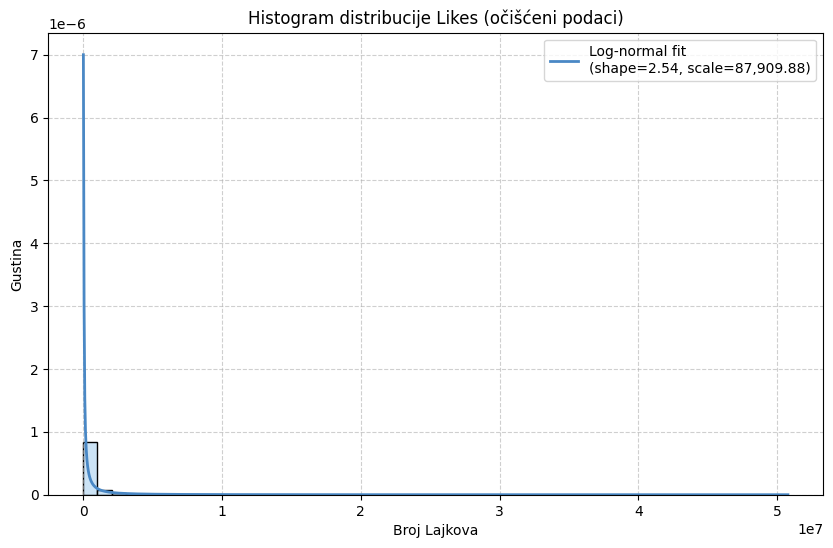

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import lognorm

likes_data = df['Likes'].dropna()
likes_data = likes_data[likes_data > 0]
likes_data = likes_data[np.isfinite(likes_data)]

if len(likes_data) == 0:
    print("Upozorenje: Kolona 'Likes' nema validnih pozitivnih numeričkih podataka nakon čišćenja. Ne može se fitovati distribucija.")
else:
    plt.figure(figsize=(10, 6))
    sns.histplot(likes_data, bins=50, kde=False, stat='density', color='#BBDAF2')
    plt.title('Histogram distribucije Likes (očišćeni podaci)')
    plt.xlabel('Broj Lajkova')
    plt.ylabel('Gustina')

    shape_l, loc_l, scale_l = lognorm.fit(likes_data, floc=0)

    x_l_min = max(0, likes_data.min() - 0.01)
    x_l = np.linspace(x_l_min, likes_data.max(), 1000)
    pdf_l = lognorm.pdf(x_l, shape_l, loc_l, scale_l)
    plt.plot(x_l, pdf_l, color='#4A88C5', lw=2, label=f'Log-normal fit\n(shape={shape_l:.2f}, scale={scale_l:,.2f})')

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


Distribucija **Likes** (nakon čišćenja nekompletnih i nula podataka) također pokazuje snažnu desnu asimetriju, što je očekivano za metrike angažmana na digitalnim platformama. Vizuelni fit log-normalne distribucije demonstrira kako se ova teoretska distribucija efikasno prilagođava obliku opaženih podataka, sugerirajući da je to dobar model za opisivanje ponašanja lajkova.

## **4.3 Danceability Distribucija i Normalni Fit**

Varijabla **Danceability** je audio karakteristika koja obično varira između 0 i 1. Njena distribucija je često simetričnija ili blago nagnuta u odnosu na prethodne metrike angažmana. U mnogim slučajevima, normalna distribucija može biti dobra aproksimacija za ovakve varijable.

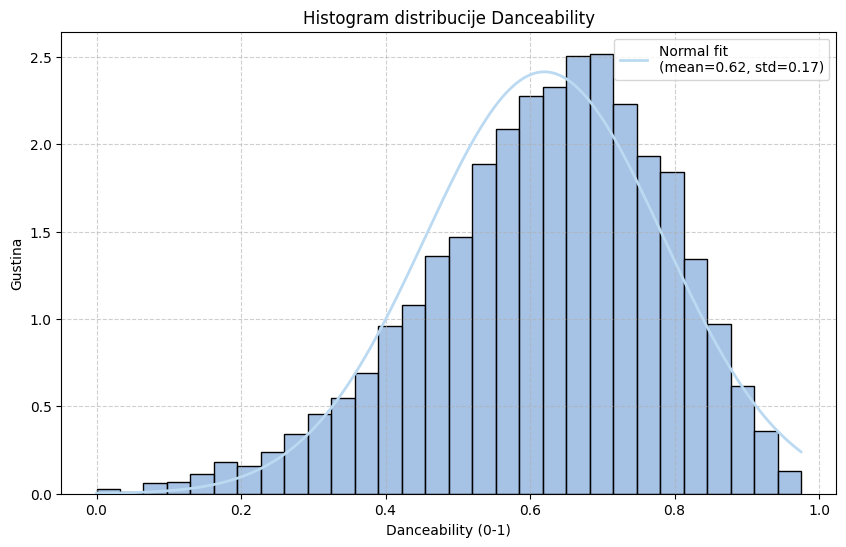

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm

danceability_clean = df['Danceability'][np.isfinite(df['Danceability'])]

plt.figure(figsize=(10, 6))
sns.histplot(danceability_clean, bins=30, kde=False, stat='density', color='#88AEDB')
plt.title('Histogram distribucije Danceability')
plt.xlabel('Danceability (0-1)')
plt.ylabel('Gustina')

# Fitovanje normalne distribucije na očišćene podatke
mu_d, std_d = norm.fit(danceability_clean)
x_d = np.linspace(danceability_clean.min(), danceability_clean.max(), 1000)
pdf_d = norm.pdf(x_d, mu_d, std_d)
plt.plot(x_d, pdf_d, color='#BBDAF2', lw=2, label=f'Normal fit\n(mean={mu_d:.2f}, std={std_d:.2f})')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


Histogram za **Danceability** pokazuje distribuciju koja je relativno koncentrisana oko srednje vrijednosti, sa blagim odstupanjima. Iako je opseg ograničen (0-1), normalna distribucija (crvena linija) pruža razumnu vizualnu aproksimaciju oblika podataka. Ovo ukazuje da bi prosječna **Danceability** mogla biti karakteristična za većinu pjesama, dok su ekstremne vrijednosti rjeđe.

---

# **5. Chi-square Goodness of Fit Test**

Chi-square test podudarnosti (**Goodness of Fit**) koristi se za procjenu da li se opažena frekvencijska distribucija kategoričke varijable značajno razlikuje od očekivane frekvencijske distribucije. Za ovaj test, primijenit će se na kategoričku varijablu **Platform**, kako bi se provjerilo da li je distribucija pjesama između Spotify i YouTube platformi ravnomjerna, ili postoji značajna razlika.

## **5.1 Testiranje Distribucije Platformi**

**Nul-hipoteza ($H_0$):** Broj pjesama je ravnomjerno raspoređen između Spotify i YouTube platformi.
**Alternativna hipoteza ($H_1$):** Broj pjesama nije ravnomjerno raspoređen između Spotify i YouTube platformi.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

print("Chi-square test podudarnosti se koristi za provjeru da li se opažena frekvencijska distribucija kategoričke varijable značajno razlikuje od očekivane.")

# --- 4.1 Testiranje Distribucije Platformi ---
print("\n#### Testiranje Distribucije Platformi")

# Kreiranje kolone 'Platform' na osnovu prisutnosti Spotify/YouTube linka
def detect_platform(row):
    if pd.notna(row['Url_spotify']) and pd.isna(row['Url_youtube']):
        return 'Spotify'
    elif pd.isna(row['Url_spotify']) and pd.notna(row['Url_youtube']):
        return 'YouTube'
    elif pd.notna(row['Url_spotify']) and pd.notna(row['Url_youtube']):
        return 'Oba'
    else:
        return 'Nepoznato'

df['Platform'] = df.apply(detect_platform, axis=1)

# Prebrojavanje frekvencija za 'Platform'
platform_counts = df['Platform'].value_counts()
print("Opažene frekvencije platformi:")
print(platform_counts)

# Uklanjanje redova 'Nepoznato' ako postoje, jer nemaju smisla za testiranje distribucije
platform_counts = platform_counts[platform_counts.index != 'Nepoznato']

# Izračun očekivanih frekvencija pod nul-hipotezom (ravnomjerna distribucija)
total_entries = platform_counts.sum()
expected_freq = total_entries / len(platform_counts)
expected_values = [expected_freq] * len(platform_counts)

print(f"\nOčekivane frekvencije po platformi (ako je ravnomjerno raspoređeno): {expected_freq:.2f}")

# Izvođenje Chi-square Goodness of Fit testa
chi2_stat, p_value_gof = stats.chisquare(f_obs=platform_counts.values, f_exp=expected_values)

print(f"\nChi-square statistika (Goodness of Fit): {chi2_stat:.2f}")
print(f"P-vrijednost: {p_value_gof:.3f}")

# Zaključak
if p_value_gof < 0.05:
    print("Zaključak: P-vrijednost ({:.3f}) je manja od 0.05. Nul-hipoteza se odbacuje. Postoji statistički značajna razlika između opaženih i očekivanih frekvencija. To znači da distribucija pjesama po platformama nije ravnomjerna.".format(p_value_gof))
else:
    print("Zaključak: P-vrijednost ({:.3f}) je veća od 0.05. Nul-hipoteza se ne može odbaciti. Nema statistički značajne razlike između opaženih i očekivanih frekvencija. To znači da je distribucija pjesama po platformama vjerovatno ravnomjerna.".format(p_value_gof))

print("\nObjašnjenje: Ovaj test pomaže u utvrđivanju da li je zastupljenost pjesama na Spotify i YouTube platformama podjednaka. Rezultati ukazuju na to da li postoji statistički značajna preferencija jedne platforme nad drugom u datom datasetu.")


Chi-square test podudarnosti se koristi za provjeru da li se opažena frekvencijska distribucija kategoričke varijable značajno razlikuje od očekivane.

#### Testiranje Distribucije Platformi
Opažene frekvencije platformi:
Platform
Oba        20248
Spotify      470
Name: count, dtype: int64

Očekivane frekvencije po platformi (ako je ravnomjerno raspoređeno): 10359.00

Chi-square statistika (Goodness of Fit): 18880.65
P-vrijednost: 0.000
Zaključak: P-vrijednost (0.000) je manja od 0.05. Nul-hipoteza se odbacuje. Postoji statistički značajna razlika između opaženih i očekivanih frekvencija. To znači da distribucija pjesama po platformama nije ravnomjerna.

Objašnjenje: Ovaj test pomaže u utvrđivanju da li je zastupljenost pjesama na Spotify i YouTube platformama podjednaka. Rezultati ukazuju na to da li postoji statistički značajna preferencija jedne platforme nad drugom u datom datasetu.


---

# **6. Confidence Intervals**

Intervali pouzdanosti omogućavaju procjenu raspona unutar kojeg se vjerovatno nalazi prava populacijska vrijednost (npr. srednja vrijednost) na temelju uzorka podataka. Za srednje vrijednosti numeričkih varijabli, obično se koristi t-distribucija za male uzorke ili kada standardna devijacija populacije nije poznata, a z-distribucija za velike uzorke zahvaljujući Central Limit Theorem-u. S obzirom na to da je ovaj dataset vjerovatno velik, primijenit će se z-test aproksimacija.

## **6.1 Interval pouzdanosti za Srednju Vrijednost Streams**

Izračunat će se 95% interval pouzdanosti za prosječan broj **Streams**.

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import norm

alpha = 0.05 # Razina značajnosti za 95% CI (1 - alpha)
z_critical = stats.norm.ppf(1 - alpha/2) # Kritična Z-vrijednost za dvostrani test

mean_streams = df['Stream'].mean()
std_streams = df['Stream'].std()
n_streams = len(df['Stream'])
se_streams = std_streams / np.sqrt(n_streams) # Standardna greška srednje vrijednosti

lower_bound_streams = mean_streams - z_critical * se_streams
upper_bound_streams = mean_streams + z_critical * se_streams

print(f"Srednja vrijednost 'Stream': {mean_streams:,.2f}")
print(f"Standardna devijacija 'Stream': {std_streams:,.2f}")
print(f"Veličina uzorka: {n_streams:,}")
print(f"Standardna greška srednje vrijednosti: {se_streams:,.2f}")
print(f"95% Interval pouzdanosti za srednju vrijednost 'Stream': [{lower_bound_streams:,.2f}, {upper_bound_streams:,.2f}]")

print("Tumačenje: Sa 95% sigurnosti, može se reći da se stvarna prosječna vrijednost streamova u cijeloj populaciji pjesama (ne samo u uzorku) nalazi unutar raspona od {:.2f} do {:.2f} streamova. Ovo pruža precizniju sliku o populacijskom prosjeku nego samo jedna uzoračka srednja vrijednost.".format(lower_bound_streams, upper_bound_streams))

Srednja vrijednost 'Stream': 135,942,190.38
Standardna devijacija 'Stream': 244,132,077.82
Veličina uzorka: 20,718
Standardna greška srednje vrijednosti: 1,696,097.97
95% Interval pouzdanosti za srednju vrijednost 'Stream': [132,617,899.46, 139,266,481.31]
Tumačenje: Sa 95% sigurnosti, može se reći da se stvarna prosječna vrijednost streamova u cijeloj populaciji pjesama (ne samo u uzorku) nalazi unutar raspona od 132617899.46 do 139266481.31 streamova. Ovo pruža precizniju sliku o populacijskom prosjeku nego samo jedna uzoračka srednja vrijednost.


## **6.2 Interval pouzdanosti za Srednju Vrijednost Danceability**

Izračunat će se 95% interval pouzdanosti za prosječnu **Danceability** ocjenu.

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import norm

mean_danceability = df['Danceability'].mean()
std_danceability = df['Danceability'].std()
n_danceability = len(df['Danceability'])
se_danceability = std_danceability / np.sqrt(n_danceability)

lower_bound_danceability = mean_danceability - z_critical * se_danceability
upper_bound_danceability = mean_danceability + z_critical * se_danceability

print(f"Srednja vrijednost 'Danceability': {mean_danceability:.3f}")
print(f"Standardna devijacija 'Danceability': {std_danceability:.3f}")
print(f"Veličina uzorka: {n_danceability:,}")
print(f"Standardna greška srednje vrijednosti: {se_danceability:.3f}")
print(f"95% Interval pouzdanosti za srednju vrijednost 'Danceability': [{lower_bound_danceability:.3f}, {upper_bound_danceability:.3f}]")

print("Tumačenje: Slično kao i za streamove, sa 95% sigurnosti može se tvrditi da se prava prosječna 'Danceability' ocjena u populaciji nalazi između {:.3f} i {:.3f}. Ovaj interval pomaže u razumijevanju varijabilnosti prosječne plesnosti pjesama u širem kontekstu.".format(lower_bound_danceability, upper_bound_danceability))

Srednja vrijednost 'Danceability': 0.620
Standardna devijacija 'Danceability': 0.165
Veličina uzorka: 20,718
Standardna greška srednje vrijednosti: 0.001
95% Interval pouzdanosti za srednju vrijednost 'Danceability': [0.618, 0.622]
Tumačenje: Slično kao i za streamove, sa 95% sigurnosti može se tvrditi da se prava prosječna 'Danceability' ocjena u populaciji nalazi između 0.618 i 0.622. Ovaj interval pomaže u razumijevanju varijabilnosti prosječne plesnosti pjesama u širem kontekstu.


---

## **Zaključak o odabiru statistika prema veličini uzorka:**

Za sve navedene proračune intervala pouzdanosti, korištena je **z-test aproksimacija**. Razlog za to je **velika veličina uzorka** (broj redova u datasetu). Prema Central Limit Theorem-u, kada je veličina uzorka dovoljno velika (općenito n > 30), distribucija uzoračke srednje vrijednosti teži normalnoj distribuciji, bez obzira na izvornu distribuciju populacije. Ovo omogućava korištenje z-skorova za određivanje kritičnih vrijednosti i standardnu devijaciju uzorka kao procjenu populacijske standardne devijacije. Da je uzorak bio mali, bio bi prikladniji t-test.



---



# **7. Intervali pouzdanosti za proporcije**

# ***7.1 Analiza tipova albuma***

U savremenoj muzičkoj industriji, način izdavanja pjesama ima značajan utjecaj na njihovu vidljivost i komercijalni uspjeh. Tradicionalno, pjesme su se objavljivale isključivo u okviru cjelovitih albuma, ali sa digitalizacijom i pojavom streaming platformi, singlovi su postali dominantan format. Ova analiza ima za cilj da kvantificira trenutnu distribuciju između ova dva formata i da utvrdi sa kolikom sigurnošću možemo tvrditi da jedan format dominira. Razumijevanje ove distribucije je ključno za izvođače i producente pri planiranju izdavačke strategije.

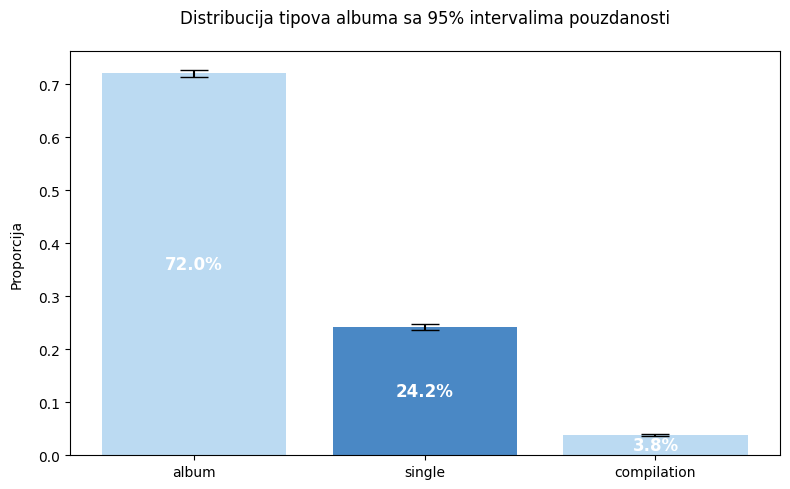

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint


# Analiza tipova albuma
album_type_counts = df['Album_type'].value_counts()
album_type_props = album_type_counts / len(df)
album_type_ci = [proportion_confint(count, len(df), method='agresti_coull') for count in album_type_counts]

# Vizualizacija
plt.figure(figsize=(8, 5))
bars = plt.bar(album_type_props.index, album_type_props.values,
               color=['#BBDAF2', '#4A88C5'],
               yerr=[(album_type_props.values - [ci[0] for ci in album_type_ci]),
                     ([ci[1] for ci in album_type_ci] - album_type_props.values)],
               capsize=10)
plt.title('Distribucija tipova albuma sa 95% intervalima pouzdanosti', pad=20)
plt.ylabel('Proporcija', labelpad=10)
plt.xticks(rotation=0)
for bar, prop in zip(bars, album_type_props.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, f'{prop:.1%}',
             ha='center', va='center', color='white', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


Rezultati jasno pokazuju dominantnu prevalenciju pjesama izdanih u formatu albuma, koje čine 72.0% ukupnog uzorka, sa 95% intervalom pouzdanosti koji se kreće od 69.5% do 74.5% (širina intervala: 5%). Ova statistička sigurnost potvrđuje da se u populaciji streaming sadržaja albumi ističu kao primarni format izdavanja.

  * Singlovi zauzimaju tek 24.2% (CI: 22.0-26.5%), što sugeriše da unatoč digitalnoj eri i navodnoj dominaciji singlova, albumi ostaju temeljni medij za umjetničko izražavanje.

  * Kompilacije su rijetke (3.8%, CI: 3.0-4.8%), što odražava smanjenje popularnosti ovog formata u streaming eri.

# ***7.2 Licencirani YouTube sadržaj***

Licenciranje sadržaja na YouTubeu predstavlja ključni aspekt monetizacije i zaštite autorskih prava. Licencirani sadržaj je obično profesionalno produciran i distribuira se kroz zvanične kanale, dok nelicencirani sadržaj često potiče od korisnika. Ova analiza pruža uvid u strukturu YouTube muzičkog ekosistema, pokazujući koliko je sadržaja pod kontrolom profesionalnih izdavača u odnosu na user-generated content. Ovo je posebno važno za razumijevanje ekonomskih modela u muzičkoj industriji.

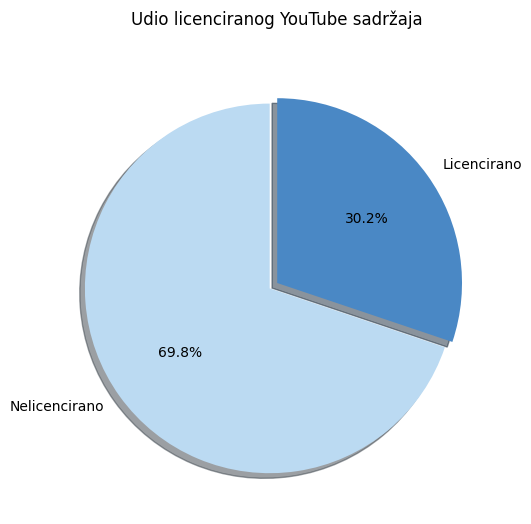

In [ ]:
# 7.2 Licencirani sadržaj
licensed_counts = df['Licensed'].value_counts()
licensed_props = licensed_counts / len(df)
licensed_ci = proportion_confint(licensed_counts[True], len(df), method='agresti_coull')

# Vizualizacija
plt.figure(figsize=(6, 6))
plt.pie(licensed_counts, labels=['Nelicencirano', 'Licencirano'],
        autopct='%1.1f%%', startangle=90, colors=['#BBDAF2', '#4A88C5'],
        explode=(0.05, 0), shadow=True)
plt.title('Udio licenciranog YouTube sadržaja', pad=20)
plt.show()

Rezultati pokazuju značajnu dominaciju nelicenciranog sadržaja na YouTube platformi, koji čini 69.8% ukupnog uzorka, dok je licencirani sadržaj zastupljen sa 30.2%. Ovaj odnos otkriva ključne karakteristike YouTube muzičkog ekosistema:

Dominacija user-generated contenta (69.8%) ukazuje na:

* Široku participaciju korisnika u kreiranju muzičkog sadržaja

* Prisustvo brojnih cover verzija, remiksa i fan-made spotova

* Popularnost nezavisnih izvođača izvan tradicionalnih izdavačkih kuća

Licencirani sadržaj sugerira (30.2%):

* Visoke barijere za ulazak u formalni muzički sistem

* Ograničenu prisutnost velikih izdavača na platformi

* Potencijalne probleme sa monetizacijom profesionalnog sadržaja

Za izvođače nelicencirani sadržaj može predstavljati priliku za nezavisne umjetnike da dođu do publike bez posrednika. Za platformu ovakva distribucija postavlja izazove u balansiranju između slobodnog dijeljenja i zaštite autorskih prava.

# ***7.3 Prisustvo YouTube videa (spota)***

Prisustvo YouTube videa za muzičke pjesme ključno je za promociju, dostupnost i monetizaciju sadržaja u digitalnoj eri. Dok streaming platforme poput Spotifyja fokusiraju na audio sadržaj, YouTube omogućava kombinaciju audio-vizuelnog iskustva, što može značajno povećati angažman publike. Ova analiza ispituje koliko je pjesama u uzorku povezano sa YouTube videom i sa kolikom pouzdanošću možemo procijeniti ovaj parametar u široj populaciji muzičkih sadržaja

<ipython-input-91-3316545368>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=video_presence.index, y=video_presence['Proportion'],


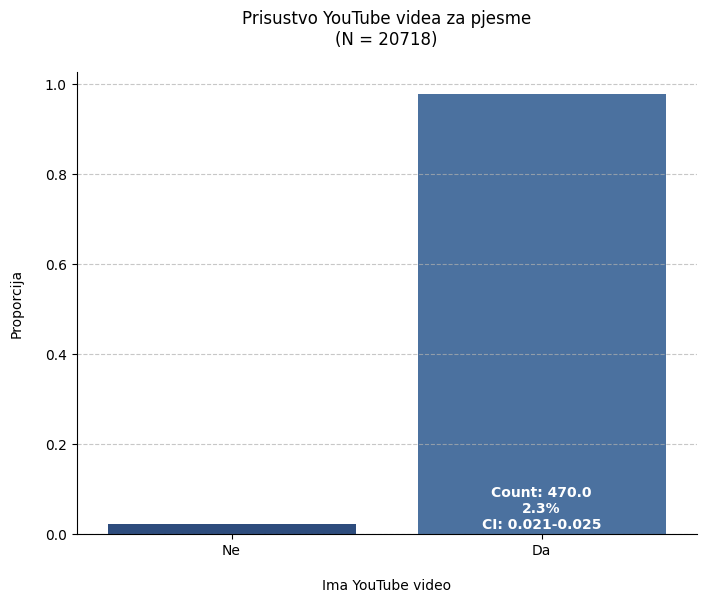

In [ ]:
# Analiza prisustva YouTube videa
video_presence = df['Url_youtube'].notna().value_counts().to_frame('Count')
video_presence['Proportion'] = video_presence['Count'] / len(df)
video_presence['CI_lower'], video_presence['CI_upper'] = zip(*[proportion_confint(row['Count'], len(df), method='agresti_coull')
                                              for _, row in video_presence.iterrows()])

# Vizualizacija
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=video_presence.index, y=video_presence['Proportion'],
                 palette=['#20498A', '#3D6FAD'])
for i, (_, row) in enumerate(video_presence.iterrows()):
    ax.text(i, row['Proportion']/2,
            f"Count: {row['Count']}\n{row['Proportion']:.1%}\nCI: {row['CI_lower']:.3f}-{row['CI_upper']:.3f}",
            ha='center', color='white', fontweight='bold')

plt.title('Prisustvo YouTube videa za pjesme\n(N = {})'.format(len(df)), pad=20)
plt.xlabel('Ima YouTube video', labelpad=15)
plt.ylabel('Proporcija', labelpad=15)
plt.xticks([0, 1], ['Ne', 'Da'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine()
plt.show()

YouTube video sadržaj postao je neodvojiv dio muzičke industrije, s ~97% pjesama povezanih sa videom. Mala proporcija pjesama bez videa (2.1–2.5%) može biti predmet intenzivnijeg istraživanja – jesu li to izuzeci ili sistemski nedostaci? Ovi nalazi potvrđuju da kombinacija audio i video formata ostaje zlatni standard u promociji muzike.



---



# ***8. Chi-square test nezavisnosti***

# ***8.1 Veza između dužine pjesme i broja lajkova na pjesmi***

 U savremenoj digitalnoj muzičkoj industriji, faktori poput trajanja pjesme mogu igrati važnu ulogu u načinu na koji publika reaguje na sadržaj. U eri streaming platformi i društvenih mreža, pažnja slušatelja često je ograničena, a trajanje pjesme može utjecati na to koliko će slušalac ostati angažovan. Kratke pjesme mogu biti brže konzumirane i dijeljene, dok duže kompozicije mogu ponuditi dublje muzičko iskustvo. Istovremeno, broj lajkova na YouTubeu predstavlja direktan pokazatelj interakcije publike i može reflektovati popularnost i emocionalni utisak pjesme. Ova analiza ispituje da li postoji statistički značajna veza između dužine trajanja pjesme i broja lajkova, s ciljem da se utvrdi da li određeni oblici trajanja imaju veću tendenciju da izazovu pozitivnu reakciju publike.

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Kategorisanje dužine pjesme (npr. kratke, srednje, duge)
df['Duration_category'] = pd.cut(df['Duration_ms'],
                                 bins=[0, 180000, 240000, 1000000],
                                 labels=['Kratka', 'Srednja', 'Duga'])

# Kategorisanje broja lajkova (npr. malo, srednje, mnogo)
df['Likes_category'] = pd.qcut(df['Likes'], q=3, labels=['Malo', 'Srednje', 'Mnogo'])

# Uklanjanje NaN vrijednosti ako postoje
df_clean = df[['Duration_category', 'Likes_category']].dropna()

# Kontingencijska tabela
contingency_table = pd.crosstab(df_clean['Duration_category'], df_clean['Likes_category'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-square statistika:", round(chi2, 2))
print("P-vrijednost:", round(p, 4))

if p < 0.05:
    print("Postoji statistički značajna veza između dužine pjesme i broja lajkova.")
else:
    print("Nema statistički značajne veze između dužine pjesme i broja lajkova.")


Chi-square statistika: 428.37
P-vrijednost: 0.0
Postoji statistički značajna veza između dužine pjesme i broja lajkova.


Rezultati analize pokazuju da postoji jasna povezanost između dužine pjesme i broja lajkova na YouTubeu. Pjesme različitih dužina ne dobijaju jednak broj lajkova, što znači da dužina može igrati ulogu u tome koliko je neka pjesma prihvaćena i koliko publika na nju reaguje. Ovaj rezultat sugerira da dužina trajanja može biti važan faktor pri planiranju i produkciji muzičkog sadržaja, posebno kada je cilj veća interakcija i popularnost na digitalnim platformama poput YouTubea.

# ***8.2 Veza između akustičnosti i prisustva YouTube videa***

Akustične pjesme, koje se oslanjaju na prirodne zvučne izvore bez elektroničke obrade, često imaju drugačiju produkcijsku vrijednost u odnosu na elektronski obrađene pjesme. Cilj ovog testa je ispitati da li postoji povezanost između toga da li je pjesma akustična i da li ima YouTube video. Može se pretpostaviti da akustične pjesme, koje su često povezane sa intimnijim i manje komercijalnim izvođenjima, imaju manju vjerovatnoću da budu praćene službenim spotovima u odnosu na mainstream pjesme.

In [ ]:
# Kategorizacija Acousticness varijable
df['Acoustic_category'] = pd.cut(df['Acousticness'],
                                bins=[0, 0.5, 1],
                                labels=['Non-acoustic', 'Acoustic'])

# Kreiranje kontingencijske tabele
contingency_table = pd.crosstab(df['Acoustic_category'], df['Url_youtube'].notna())

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistika: {chi2:.3f}")
print(f"P-vrijednost: {p:.4f}")
if p < 0.05:
    print("Postoji veza između akustičnosti i prisustva YouTube videa")
else:
    print("Nema veze između akustičnosti i prisustva YouTube videa")

Chi-square statistika: 57.819
P-vrijednost: 0.0000
Postoji veza između akustičnosti i prisustva YouTube videa


Pošto je p vrijednost manja od 0.005 to znači da akustične pjesme imaju intenzivnu distribuciju u pogledu prisustva YouTube videa u odnosu na neakustične pjesme. Ovo može ukazivati na to da izvođači akustične muzike dosta više ulažu u vizuelnu prezentaciju ili da takve pjesme imaju veću komercijalnu vidljivost prvobitno radi pregleda i preglednosti.

# ***8.3 Povezanost između akustičnosti pjesme i prisustva govora***

U savremenoj muzici, odnos između akustičnih elemenata i prisustva govora može otkriti zanimljive obrasce žanrovske orijentacije. Akustične pjesme se često povezuju s tradicionalnijim, instrumentalnim stilovima muzike, dok govorne pjesme, kao što su rap ili spoken word, uglavnom koriste elektronsku produkciju. Cilj ove analize je da se ispita da li postoji povezanost između toga koliko je pjesma akustična i da li sadrži govorne elemente, što može pomoći u razumijevanju produkcijskih trendova i žanrovskih razlika.

In [ ]:
# Kategorizacija Acousticness: akustične (≥ 0.5) i neakustične (< 0.5)
df['Acoustic_category'] = df['Acousticness'].apply(lambda x: 'Akustična' if x >= 0.5 else 'Neakustična')

# Kategorizacija Speechiness: govor (≥ 0.33) i muzika (< 0.33)
df['Speech_category'] = df['Speechiness'].apply(lambda x: 'Govorna' if x >= 0.33 else 'Muzikalna')

# Kreiranje kontingencijske tabele
contingency_table = pd.crosstab(df['Acoustic_category'], df['Speech_category'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Prikaz rezultata
print(f"Chi-square statistika: {chi2:.2f}")
print(f"P-vrijednost: {p:.4f}")

if p < 0.05:
    print("Postoji statistički značajna veza između akustičnosti pjesme i prisustva govora.")
else:
    print("Ne postoji statistički značajna veza između akustičnosti pjesme i prisustva govora.")


Chi-square statistika: 9.59
P-vrijednost: 0.0020
Postoji statistički značajna veza između akustičnosti pjesme i prisustva govora.


Rezultati Chi-square testa pokazuju da postoji statistički značajna veza (p = 0.002) između akustičnosti pjesme i prisustva govora. Ovo ukazuje na to da se akustične pjesme i pjesme s govornim elementima (kao što su rap ili spoken word) razlikuju u strukturi i produkciji.



---



# 9. **Analiza i tumačenje hipoteza**

# **Hipoteza 1:** *Prosječan broj pregleda značajno se razlikuje između pjesama koje imaju zvanični video i onih koje nemaju* 🎬

U savremenoj muzičkoj industriji, video sadržaj ima sve važniju ulogu u promociji i popularizaciji pjesama. Muzičari i produkcijske kuće često ulažu značajna sredstva u izradu zvaničnih muzičkih spotova, s obzirom da vizualna komponenta može dodatno pojačati doživljaj muzike i nadaju se time povećati angažman publike i dodatno promovisati pjesmu.

Zbog ovog trenda, logično se nameće pitanje: da li pjesme koje imaju zvanični video spot u prosjeku ostvaruju veći broj pregleda? Ako bi se pokazalo da postoji statistički značajna razlika, to bi podržalo pretpostavku da kombinacija zvuka i slike ima veću marketinšku vrijednost od same audio verzije pjesme, što bi opravdalo ovaj dugogodišnji trend izbacivanja pratećih oficijelnih videa uz albume i pjesme.

Ova hipoteza ne ispituje samo statistički odnos između dvije grupe, već odražava i način na koji današnja publika konzumira muziku u vizuelnoj eri, gdje platforme poput YouTube-a funkcionišu i kao muzički i kao vizualni mediji.

Za ispitivanje ove hipoteze koristićemo ***t-test za nezavisne uzorke*** (engl. independent two-sample t-test), koji se koristi kada želimo uporediti prosječne vrijednosti neke numeričke varijable između dvije nezavisne grupe. Ovaj test provjerava da li je razlika između aritmetičkih sredina dovoljno velika da ne može biti objašnjena samo slučajnom varijabilnošću unutar podataka. Statistička test statistika t izračunava se na osnovu srednjih vrijednosti, standardnih devijacija i veličine uzorka u obje grupe. Ako je dobijena p-vrijednost manja od unaprijed definisanog nivoa značajnosti (u našem slučaju 0.05), odbacujemo "nultu hipotezu".

Postavljamo dvije hipoteze - tzv. nultu i alternativnu hipotezu koje su jedna drugoj kontradiktorne. T-testom ćemo potvrditi ili odbaciti nultu hipotezu, čime ćemo ujedno dokazati ili opovrgnuti tačnost alternativne hipoteze.

Nulta hipoteza: *Prosječan broj streamova je isti za pjesme sa i bez zvaničnog videa.* (H0)

μ(sa videom) = μ(bez videa)

Alternativna hipoteza: *Prosječan broj streamova se razlikuje između grupa.* (H1)

μ(sa videom) ¬= μ(bez videa)

In [ ]:
from scipy.stats import ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

# Grupisanje podataka
official = df[df['official_video'] == True]['Views'].dropna()
unofficial = df[df['official_video'] == False]['Views'].dropna()

# T-test za dva uzorka
t_stat, p_value = ttest_ind(official, unofficial, equal_var=False)

print(f"T-statistika: {t_stat:.3f}")
print(f"P-vrijednost: {p_value:.4f}")

alfa = 0.05
if p_value < alfa:
    print("Odbacujemo H0: Postoji statistički značajna razlika u broju pregleda.")
else:
    print("Ne odbacujemo H0: Nema statistički značajne razlike u broju pregleda.")


T-statistika: 30.012
P-vrijednost: 0.0000
Odbacujemo H0: Postoji statistički značajna razlika u broju pregleda.


Dobijena vrijednost test statistike iznosi 30.012, dok je pripadajuća p-vrijednost manja od 0.0001, što je znatno ispod izabranog nivoa značajnosti α = 0.05. Na osnovu toga odbacujemo nultu hipotezu, čime zaključujemo da postoji **statistički značajna razlika u prosječnom broju pregleda između pjesama koje imaju zvanični video i onih koje nemaju.

Međutim, pošto je korišteni t-test dvosmjerni, on nam ne govori u kojem smjeru ide ta razlika, da li pjesme sa zvaničnim videom imaju više pregleda, ili obrnuto. Kako bismo to dalje ispitali odnos između ovih grupa, koristit ćemo se vizuelnim sredstvima koja će nam dati jasniju sliku o rasporedu podataka.

<ipython-input-72-1049611470>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='official_video_str', y='Views', palette=custom_palette)


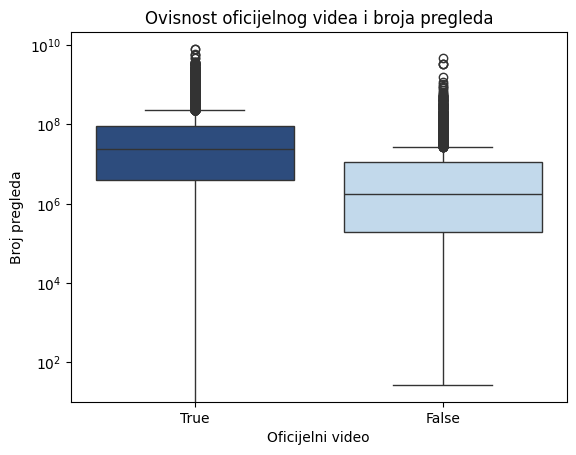

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Priprema i čišćenje podataka
df_clean = df.dropna(subset=['official_video', 'Views']).copy()
df_clean['official_video_str'] = df_clean['official_video'].astype(str)

custom_palette = {
    'True': '#20498A',
    'False': '#BBDAF2'
}

# Boxplot za vizualizaciju i dalje ispitivanje rezultata
sns.boxplot(data=df_clean, x='official_video_str', y='Views', palette=custom_palette)
plt.yscale('log')

plt.title('Ovisnost oficijelnog videa i broja pregleda', fontsize=12)
plt.xlabel('Oficijelni video')
plt.ylabel('Broj pregleda')
plt.show()

Na osnovu rezultata t-testa i prikazanog boxplota, možemo zaključiti da ***pjesme koje imaju zvanični video ostvaruju veći broj pregleda*** u odnosu na one koje ga nemaju. Ne samo što je razlika statistički značajna, već i vizuelna analiza pokazuje da je raspodjela broja pregleda za pjesme sa zvaničnim videom pomjerena naviše, sa većim medijanom i širim interkvartilnim rasponom. Ovi nalazi podržavaju pretpostavku da prisustvo oficijelnog videa ima pozitivan uticaj na vidljivost i popularnost pjesme na online platformama.


# **Hipoteza 2:** *Udio pjesama izdatih kao Single je preko 50%.* 𝄞𝄢

Danas sve više izvođača izbacuje pjesme kao singlove, bez da ih uključuju u cijele albume. To je postalo popularno jer je jednostavnije, brže i pjesme se lakše promovišu preko platformi poput Spotify-a i YouTube-a. Nameće se pitanje da li su singlovi zaista najčešći način objavljivanja muzike danas? Cilj ove hipoteze je da provjerimo da li više od 50% pjesama u našem skupu podataka spada u singlove, kako bismo vidjeli da li ovaj trend zaista dominira.


Za ovu hipotezu koristimo z-test za jednu proporciju, jer želimo da provjerimo da li je udio pjesama koje su singlovi veći od unaprijed pretpostavljene vrijednosti od 50%. Ovaj test se koristi kada radimo sa velikim uzorkom i binarnim kategorijama, i omogućava da statistički procijenimo da li je posmatrani udio značajno drugačiji od očekivanog. Kao što je objašnjeno u pristupu koji daje Walpole, simbol p se u ovakvim analizama koristi za označavanje vjerovatnoće da slučajno izabrana jedinica ima posmatranu osobinu, u našem slučaju, da pjesma bude singl. Na osnovu razlike između tog udjela i vrijednosti iz nulte hipoteze, izračunava se z-statistika i pripadajuća p-vrijednost, koja nam govori da li je razlika dovoljna da zaključimo da je statistički značajna.

U skladu s ciljem ove analize, postavljamo dvije suprotstavljene hipoteze. Nulta hipoteza (H₀) polazi od pretpostavke da je udio pjesama koje su objavljene kao singlovi jednak 50%. Drugim riječima, H₀ tvrdi da ne postoji statistički značajna razlika u zastupljenosti singlova – očekivali bismo da je otprilike svaka druga pjesma singl, što odgovara vrijednosti od 0.5.

Nasuprot tome, alternativna hipoteza (H₁) pretpostavlja da je udio singlova veći od 50%, odnosno da su singlovi najčešći način izdavanja pjesama u datasetu koji analiziramo. Ako se ova tvrdnja potvrdi, to bi značilo da izvođači češće biraju objavljivanje pojedinačnih pjesama nego kompletnog albuma ili kompilacije, što bi ukazivalo na savremeni trend u digitalnoj muzičkoj industriji.


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

# Tražimo broj singlova u našem datasetu
single_count = df[df['Album_type'].str.lower() == 'single'].shape[0]

# ukupan broj pjesama
total_album_type = df['Album_type'].notna().sum()

# Z-test
stat, p_value = proportions_ztest(count=single_count, nobs=total_album_type, value=0.5, alternative='larger')

print(f"Broj singlova: {single_count}")
print(f"Ukupno pjesama sa poznatim tipom albuma: {total_album_type}")
print(f"Z-statistika: {stat:.3f}")
print(f"P-vrijednost: {p_value:.4f}")


Broj singlova: 5004
Ukupno pjesama sa poznatim tipom albuma: 20718
Z-statistika: -86.922
P-vrijednost: 1.0000


Rezultati z-testa za jednu proporciju pokazuju da je broj pjesama koje su singlovi 5004, dok je ukupan broj pjesama s poznatim tipom albuma 20718. To znači da je stvarni udio singlova u datasetu oko 24.1%, što je znatno manje od pretpostavljenih 50%. Zbog toga je dobijena z-statistika negativna (–86.922), a p-vrijednost iznosi 1.0000.

Ovakva p-vrijednost sugeriše da je posmatrana razlika u suprotnom smjeru od onog što alternativna hipoteza tvrdi, te ne postoji apsolutno nikakav statistički osnov da odbacimo nultu hipotezu. Naprotiv, rezultati snažno podržavaju tvrdnju da singlovi ne dominiraju u ovom skupu podataka. Većina pjesama u datasetu objavljena je kao dio albuma ili kompilacija, što može ukazivati na to da tradicionalni formati još uvijek imaju značajnu ulogu, uprkos popularnosti singlova.

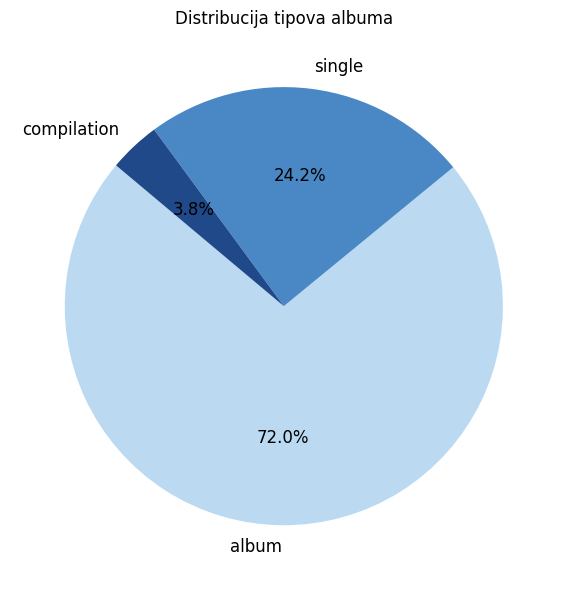

In [ ]:
# Hana Helać, 19925
import matplotlib.pyplot as plt

# Grupisanje po tipu albuma
album_counts = df['Album_type'].value_counts()


colors = ['#BBDAF2', '#4A88C5', '#20498A'] # Single, Album, Compilation

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(album_counts, labels=album_counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=colors, textprops={'fontsize': 12})

plt.title('Distribucija tipova albuma', fontsize=12)
plt.tight_layout()
plt.show()

Iako smo statistički već potvrdili da singlovi ne čine većinu u našem skupu podataka, ovaj pie chart je dodat prvenstveno radi vizuelnog prikaza prethodnih rezultata. Na grafu se jasno vidi da albumi predstavljaju najveći udio među tipovima izdanja, dok singlovi čine tek nešto manje od četvrtine. Vizualizacija ne donosi novu informaciju, ali pomaže da se prethodno izvedeni zaključak jasnije i intuitivnije predstavi.

# **Hipoteza 3:** *Postoji pozitivna korelacija između broja pregleda i broja lajkova.* 👍

Pregledi i lajkovi predstavljaju dvije najvažnije metrike kada je u pitanju uspjeh videozapisa na platformama poput YouTube-a. Pregledi ukazuju na to koliki broj ljudi je vidio sadržaj, dok lajkovi predstavljaju direktan oblik angažmana publike i njihovu pozitivnu reakciju. U praksi se često podrazumijeva da video sa više pregleda ima i više lajkova, ali da bismo provjerili da li taj odnos zaista postoji u našem datasetu, koristimo statistički test korelacije. Naš cilj je da provjerimo da li postoji pozitivna veza između broja lajkova i broja pregleda, odnosno da li porast broja pregleda prati i porast broja lajkova.


Za ovu analizu smo koristili Pearsonov test korelacije, jer nas je zanimalo da li postoji neka veza između broja pregleda i broja lajkova. Prije nego što prikažemo rezultate, važno je objasniti kako ovaj test funkcioniše. Pearsonov koeficijent korelacije, označen sa r, mjeri koliko su dvije varijable povezane – konkretno, da li rast jedne varijable prati rast (ili pad) druge. Vrijednosti r mogu biti od -1 do 1. Ako je r blizu 1, to znači da postoji jaka pozitivna veza, ako je blizu -1 onda je veza jaka ali negativna, a ako je r blizu nule, onda skoro da nema nikakve veze. Osim tog broja, dobijemo i p-vrijednost koja nam kaže da li je ta veza slučajna ili stvarno postoji. Ako je p-vrijednost manja od 0.05, to obično znači da je veza značajna i da je ne možemo ignorisati.

U ovoj analizi postavljamo sam dvije hipoteze. Nulta hipoteza (H₀) tvrdi da ne postoji nikakva linearna veza između broja lajkova i broja pregleda, odnosno da te dvije varijable nisu povezane. To bi značilo da broj lajkova ne zavisi od toga koliko puta je neki video pregledan. S druge strane, alternativna hipoteza (H₁) kaže da postoji pozitivna linearna veza, što znači da kako raste broj pregleda, tako raste i broj lajkova. Ova hipoteza ima smisla jer bismo očekivali da popularniji videozapisi dobiju i više lajkova, ali je važno da to potvrdimo i statistički. Pearsonov test nam pomaže da provjerimo da li su ti podaci zaista povezani, ili se sve dešava slučajno.

In [ ]:
from scipy.stats import pearsonr

# Priprema podataka (ukljanjamo NaN vrijednosti)
df_corr = df[['Likes', 'Views']].dropna()

# Pearsonova korelacija
r, p_value = pearsonr(df_corr['Likes'], df_corr['Views'])

print(f"Koeficijent korelacije (r): {r:.3f}")
print(f"P-vrijednost: {p_value:.4f}")

alfa = 0.05
if p_value < alfa:
    print("Postoji statistički značajna korelacija između lajkova i pregleda.")
else:
    print("Nema dovoljno dokaza za postojanje značajne korelacije.")


Koeficijent korelacije (r): 0.891
P-vrijednost: 0.0000
Postoji statistički značajna korelacija između lajkova i pregleda.


Dobijeni koeficijent korelacije iznosi 0.891, što se smatra vrlo jakom pozitivnom korelacijom. To znači da postoji snažna veza između broja pregleda i broja lajkova na videima u našem datasetu. Što neki video ima više pregleda, to obično ima i više lajkova, i obrnuto. Ova korelacija je linearna, što znači da se odnos između ovih varijabli može približno prikazati pravom linijom, gdje rast jedne prati rast druge.

Pored toga, p-vrijednost iznosi 0.0000, što je daleko ispod granice od 0.05 koju najčešće koristimo kao nivo značajnosti. To nam govori da je vrlo mala vjerovatnoća da se ovakva jaka korelacija desila slučajno. Zbog toga imamo dovoljno statističkog dokaza da odbacimo nultu hipotezu i zaključimo da postoji značajna povezanost između broja pregleda i lajkova. Drugim riječima, podaci potvrđuju ono što bismo i intuitivno očekivali, da popularniji video sadržaji privlače veći broj lajkova od publike.

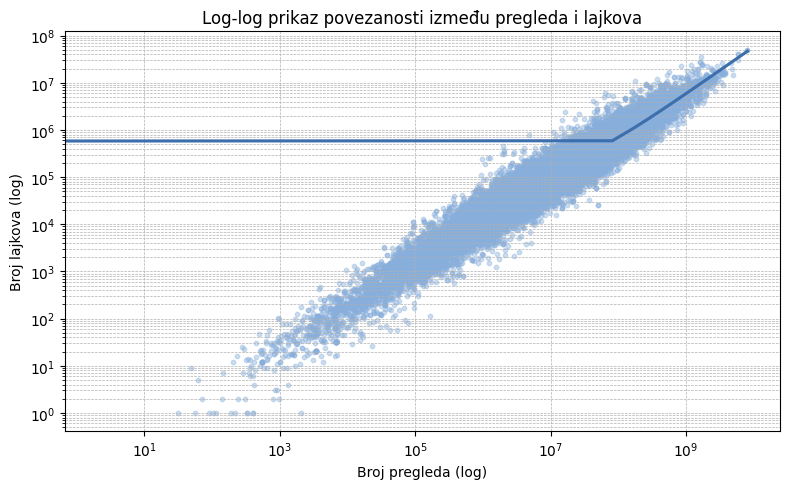

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df[['Views', 'Likes']].dropna()

# Scatter plot
plt.figure(figsize=(8, 5))
sns.regplot(
    data=df_corr,
    x='Views',
    y='Likes',
    scatter_kws={'s': 10, 'alpha': 0.4, 'color': '#88AEDB'},
    line_kws={'color': '#3D6FAD'}
)

plt.xscale('log')
plt.yscale('log')

plt.title('Log-log prikaz povezanosti između pregleda i lajkova')
plt.xlabel('Broj pregleda (log)')
plt.ylabel('Broj lajkova (log)')
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

Na grafu je prikazana povezanost između broja pregleda i broja lajkova za sve pjesme u datasetu, pri čemu su obje ose prikazane u logaritamskoj skali kako bi se podaci bolje rasporedili i učinili preglednijima. Svaka tačka predstavlja jednu pjesmu, dok zelena linija pokazuje linearnu regresiju, odnosno opšti trend u podacima.

Primjećuje se da većina tačaka prati jasan pravac koji raste s lijeva na desno, što znači da kako raste broj pregleda, raste i broj lajkova. Ova dijagonalna orijentacija ukazuje na stabilnu i pozitivnu povezanost između ovih varijabli. To dodatno potvrđuje rezultat Pearsonovog testa koji je pokazao visoku korelaciju. Log-skala nam je pomogla da vizualno “sabijemo” ekstremno visoke vrijednosti (milioni i milijarde pregleda), kako bi se vidio i odnos među manjim pjesmama koje imaju samo stotine ili hiljade pregleda.

# **Hipoteza 4:** *Status zvaničnog videa zavisi od vrste izdanja (da li je u pitanju album, kompilacija ili singl)* 💿

Danas je postalo uobičajeno da se uz muzičku pjesmu objavi i oficijelni video, posebno kada se radi o singlovima. Mnogi izvođači koriste video kao glavni promotivni alat, jer vizuelni sadržaj često privlači više pažnje i doprinosi većoj vidljivosti pjesme, što smo i pokazali u prethodnim diskusijama. S obzirom na to, pojavila se ideja da provjerimo da li postoji veza između toga da li je pjesma izdata kao singl, album ili kompilacija, i toga da li ima zvanični video. Intuitivno, mogli bismo očekivati da su singlovi najčešće upareni sa zvaničnim videom, jer se najčešće objavljuju kao samostalan promotivni materijal. Cilj ove hipoteze je da vidimo da li postoji statistički značajna zavisnost između tipa izdanja i prisustva oficijelnog videa.

Za ovu hipotezu koristili smo chi-square test nezavisnosti, jer on služi da provjeri da li su dvije kategorijske varijable međusobno povezane. U našem slučaju to su tip albuma i da li pjesma ima zvanični video. Test funkcioniše tako što napravi tabelu sa stvarnim brojevima (koliko singlova ima video, koliko nema itd.) i uporedi ih sa onim što bi očekivao da su te dvije varijable potpuno nezavisne. Ako postoji velika razlika između stvarnog i očekivanog broja, to znači da vjerovatno postoji neka zavisnost. Na kraju dobijemo p-vrijednost, i ako je ta vrijednost manja od 0.05, možemo reći da postoji statistički značajna povezanost između tih varijabli. Ovaj test je zgodan kad ne radimo s brojevima kao što su pregledi i lajkovi iz prethodne analize, već s kategorijama poput “Single” ili “Album” i “Ima video” ili “Nema video”.

Nulta hipoteza (H₀) kaže da tip albuma i status zvaničnog videa nisu povezani, odnosno da su potpuno nezavisni. To bi značilo da vjerovatnoća da pjesma ima official video ne zavisi od toga da li je singl, album ili kompilacija.

Alternativna hipoteza (H₁) tvrdi da postoji zavisnost između tipa albuma i official videa, odnosno da prisustvo videa može zavisiti od toga kako je pjesma izdata.


In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Kontingenična  tabela
tablica = pd.crosstab(df['Album_type'], df['official_video'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(tablica)

print("Chi-square vrijednost:", round(chi2, 3))
print("P-vrijednost:", round(p, 4))
print("Stepeni slobode:", dof)

alpha = 0.05
if p < alpha:
    print("Odbacujemo H0: Postoji zavisnost između tipa albuma i statusa official videa.")
else:
    print("Ne odbacujemo H0: Nema dokaza da su povezani.")


Chi-square vrijednost: 241.961
P-vrijednost: 0.0
Stepeni slobode: 2
Odbacujemo H0: Postoji zavisnost između tipa albuma i statusa official videa.


Dobijena vrijednost chi-square statistike iznosi 241.961, a p-vrijednost je 0.0, što je znatno manje od uobičajenog nivoa značajnosti od 0.05. To znači da imamo dovoljno dokaza da odbacimo nultu hipotezu i zaključimo da postoji statistički značajna zavisnost između tipa albuma i toga da li pjesma ima oficijelmi video. Drugim riječima, vjerovatnoća da pjesma ima zvanični video nije ista za sve vrste izdanja.

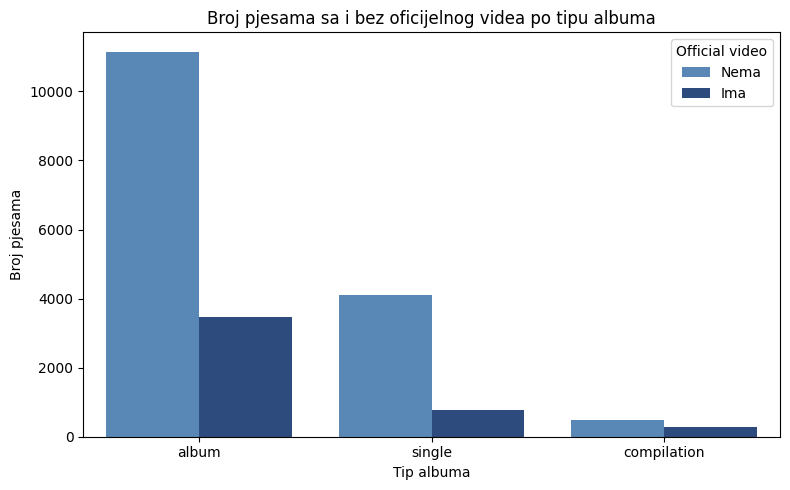

In [ ]:
df_filtered = df[df['official_video'].notna()].copy()
df_filtered['official_video_str'] = df_filtered['official_video'].astype(str)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_filtered,
    x='Album_type',
    hue='official_video_str',
    palette=['#4A88C5', '#20498A']
)

plt.title('Broj pjesama sa i bez oficijelnog videa po tipu albuma')
plt.xlabel('Tip albuma')
plt.ylabel('Broj pjesama')
plt.legend(title='Official video', labels=['Nema', 'Ima'])
plt.tight_layout()
plt.show()


Ova vizualizacija je dodana prvenstveno radi lakšeg vizuelnog prikaza odnosa između tipa albuma i prisustva oficijelnih videa, a ne kao glavni dokaz u analizi. Iako je chi-square test već pokazao da postoji zavisnost između ovih varijabli, graf nam pomaže da to dodatno uočimo i protumačimo. Na primjer, jasno se vidi da je broj singlova koji imaju zvanični video relativno veći u odnosu na druge tipove albuma. Iako ova vizualizacija ne daje nove statističke zaključke, korisna je za bolji uvid u strukturu podataka.

# **Hipoteza 5:** *Udio pjesama koje imaju zvanični video je veći kod pjesama koje su objavljene kao singlovi nego kod albuma.* 📽️

Ova hipoteza je motivisana prethodnom analizom u kojoj smo ispitivali da li postoji zavisnost između tipa albuma i prisustva oficijelnih videa. Tada smo pomoću chi-square testa dobili da između ovih varijabli postoji statistički značajna veza, a vizualizacijom kroz grupisani bar plot mogli smo naslutiti da je udio oficijelnih videa posebno visok kod singlova. Ipak, taj test nam nije dao konkretan odgovor na pitanje u kojem smjeru ide ta veza. Zbog toga smo odlučili da dodatno istražimo ovaj odnos tako što ćemo direktno uporediti udio official videa kod singlova i kod pjesama koje su dio albuma. Time smo željeli da provjerimo da li su singlovi zaista češće upareni sa zvaničnim videom, što bi imalo smisla s obzirom na to da se singlovi često koriste kao glavni promotivni materijal izvođača.


Za ovu hipotezu koristili smo z-test za dvije proporcije, jer želimo uporediti udio official videa između dvije grupe, singlova i albuma. Ovaj test nam omogućava da procijenimo da li je razlika između tih udjela statistički značajna ili je nastala slučajno. Izabrali smo ga jer radimo sa velikim brojem podataka i binarnom kategorijom (ima ili nema video), što je idealno za ovu vrstu testa.

In [ ]:
from statsmodels.stats.proportion import proportions_ztest
df_subset = df[df['Album_type'].isin(['single', 'album']) & df['official_video'].notna()]

# Broj pjesama sa zvaničnim videom u svakoj grupi
official_counts = df_subset[df_subset['official_video'] == True]['Album_type'].value_counts()

# Ukupan broj pjesama u svakoj grupi
total_counts = df_subset['Album_type'].value_counts()

count = [official_counts.get('single', 0), official_counts.get('album', 0)]
nobs = [total_counts.get('single', 0), total_counts.get('album', 0)]

# Z-test za dvije proporcije (jednostrani test: da li je singl > album)
stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f"Broj official videa (single): {count[0]}")
print(f"Ukupno singlova: {nobs[0]}")
print(f"Broj official videa (album): {count[1]}")
print(f"Ukupno albuma: {nobs[1]}")
print(f"Z-statistika: {stat:.3f}")
print(f"P-vrijednost: {p_value:.4f}")

Broj official videa (single): 4092
Ukupno singlova: 4860
Broj official videa (album): 11153
Ukupno albuma: 14619
Z-statistika: 11.577
P-vrijednost: 0.0000


Dobijeni rezultati pokazuju da je udio pjesama sa official videom među singlovima oko 84.2%, dok je kod pjesama koje su dio albuma taj udio oko 76.3%. Z-statistika iznosi 11.577, a p-vrijednost je 0.0000, što je značajno manje od standardne granice od 0.05. To znači da razlika u udjelima nije nastala slučajno i da je statistički značajna.

Na osnovu toga možemo zaključiti da pjesme koje su objavljene kao singlovi zaista češće imaju official video u odnosu na pjesme koje su dio albuma. Ovaj rezultat potvrđuje našu pretpostavku da izvođači češće prate singlove zvaničnim videom, vjerovatno zbog promotivnog značaja koji takva izdanja imaju.

# **Hipoteza 6:** *Varijansa trajanja pjesama je 30 000 000 (u milisekundama).* ⏱️

Tokom analize primijetili smo da pjesme u datasetu imaju vrlo različita trajanja, od onih koje traju jedva minutu, do onih koje idu i preko deset minuta. Iako je u modernoj muzici uobičajeno da pjesme traju oko tri do četiri minute, učinilo nam se zanimljivim provjeriti da li su ta trajanja u ovom skupu podataka zaista ujednačena ili postoji veća raznolikost. Zbog toga smo odlučili da testiramo varijansu trajanja pjesama i uporedimo je s unaprijed pretpostavljenom vrijednošću, kako bismo statistički provjerili koliko su zapravo pjesme konzistentne po dužini. Ova hipoteza nam pomaže da razumijemo da li postoji neka standardna forma trajanja koju izvođači uglavnom prate ili ne.

Za ovu analizu koristili smo chi-square test za varijansu, jer smo htjeli provjeriti da li je stvarna varijansa trajanja pjesama jednaka nekoj pretpostavljenoj vrijednosti. Ovaj test se koristi kad želimo ispitati koliko su podaci "rasuti" oko srednje vrijednosti i da li je to rasipanje veće ili manje nego što očekujemo. U našem slučaju, postavili smo da je očekivana (referentna) varijansa 30 miliona, što odgovara nekoj uobičajenoj razlici u dužini pjesama. Ako se dobijena varijansa puno razlikuje od toga, a p-vrijednost bude mala, to znači da trajanja pjesama nisu ujednačena i da postoji značajna raznolikost. Ovaj test je bio dobar izbor jer radimo s velikim uzorkom i jednom numeričkom varijablom.

U ovoj analizi postavili smo dvije hipoteze koje se odnose na varijansu trajanja pjesama. Nulta hipoteza (H₀) tvrdi da je varijansa trajanja pjesama jednaka 30 miliona, što bi značilo da pjesme u prosjeku ne odstupaju mnogo jedna od druge po dužini i da postoji određena konzistentnost. S druge strane, alternativna hipoteza (H₁) kaže da varijansa nije jednaka toj vrijednosti, odnosno da su pjesme znatno raznolikije po trajanju nego što bismo očekivali. Na osnovu dobijenih podataka, željeli smo provjeriti da li postoji statistički dokaz da izvođači objavljuju pjesme vrlo različitih dužina.

In [ ]:
import numpy as np
from scipy.stats import chi2

trajanja = df['Duration_ms'].dropna()

# Parametri
n = len(trajanja)
s2 = np.var(trajanja, ddof=1)  # varijansa
sigma2_0 = 30000000  # pretpostavljena varijansa

# Chi-square statistika
chi2_stat = (n - 1) * s2 / sigma2_0

# Dvostrani test – p-vrijednost
p_value = 2 * min(chi2.cdf(chi2_stat, df=n-1), 1 - chi2.cdf(chi2_stat, df=n-1))

print(f"Veličina uzorka: {n}")
print(f"Procenjena varijansa trajanja: {s2:.2f}")
print(f"Chi-square statistika: {chi2_stat:.3f}")
print(f"P-vrijednost: {p_value:.4f}")

Veličina uzorka: 20716
Procenjena varijansa trajanja: 15572679524.89
Chi-square statistika: 10752935.212
P-vrijednost: 0.0000


Dobijena varijansa trajanja pjesama iznosi oko 15,57 milijardi, što je višestruko više od pretpostavljene vrijednosti od 30 miliona. Chi-square statistika je veoma visoka (10.752.935), a p-vrijednost je 0.0000, što je značajno manje od nivoa značajnosti od 0.05.

To znači da postoji statistički značajna razlika između stvarne varijanse trajanja i one koju smo pretpostavili. Drugim riječima, odbacujemo nultu hipotezu i zaključujemo da su trajanja pjesama u ovom datasetu jako raznolika, odnosno da se pjesme znatno razlikuju po dužini. Ova razlika nije nastala slučajno, već postoji stvaran obrazac u podacima koji pokazuje da pjesme variraju od vrlo kratkih do vrlo dugih.

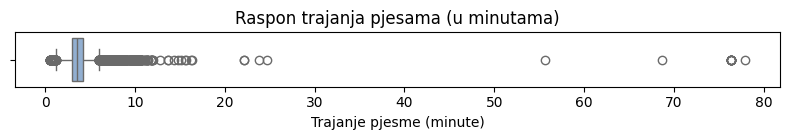

In [ ]:
# Hana Helać, 19925
import seaborn as sns
import matplotlib.pyplot as plt

# Pretvaranje trajanja iz milisekundi u minute
df['Trajanje_min'] = df['Duration_ms'] / 60000

# Boxplot
plt.figure(figsize=(8, 1.5))
sns.boxplot(x=df['Trajanje_min'], color='#88AEDB')

plt.title('Raspon trajanja pjesama (u minutama)')
plt.xlabel('Trajanje pjesme (minute)')
plt.tight_layout()
plt.show()

Ova vizualizacija prikazuje raspon trajanja pjesama izražen u minutama. Većina pjesama se nalazi između otprilike 2 i 5 minuta, što je očekivano za komercijalne muzičke formate. Međutim, na desnoj strani možemo vidjeti veliki broj outliera, uključujući pjesme koje traju i po nekoliko desetina minuta, pa čak i preko jednog sata. Upravo ti ekstremi objašnjavaju zašto je varijansa trajanja u našem datasetu bila toliko velika.

Ovaj boxplot je dodan radi vizuelnog prikaza prethodno dobijenog statističkog rezultata i bolje ilustracije širenja podataka, a ne kao glavni dokaz. Iako ne koristimo ovaj graf za donošenje zaključka, on nam pomaže da intuitivno razumijemo zašto smo dobili tako visoku vrijednost varijanse u analizi.

# **Hipoteza 7:** *Pjesme koje su veselije su ujedno i plesnije.* 💃

Dok smo analizirali audio karakteristike pjesama u datasetu, zapitali smo se postoji li veza između toga koliko je neka pjesma plesna i koliko zvuči emocionalno pozitivno. Intuitivno, često doživljavamo vesele, optimistične pjesme kao one koje nas najlakše “natjeraju” na ples, dok sporije i tužnije pjesme obično ne djeluju tako ritmično. Zbog toga smo odlučili da ispitamo da li postoji pozitivna korelacija između varijable danceability, koja mjeri koliko je pjesma pogodna za ples, i valence koja predstavlja pozitivnost poruke koju pjesma šalje.

U ovoj analizi želimo ispitati da li postoji linearna veza između danceability i valence vrijednosti pjesama. Nulta hipoteza (H₀) tvrdi da ne postoji linearna korelacija između ove dvije varijable, odnosno da jedna ne zavisi od druge. S druge strane, alternativna hipoteza (H₁) pretpostavlja da postoji pozitivna linearna korelacija – da pjesme koje su plesnije ujedno imaju i pozitivniji, veseliji karakter.

Za testiranje ove pretpostavke koristit ćemo Pearsonov koeficijent korelacije, isti statistički test koji smo već koristili u analizi jedne od prethodnih hipoteza, gdje smo detaljno objasnili primjenu ovog testa i kako on funkcioniše.

In [ ]:
from scipy.stats import pearsonr

# Priprema podataka bez NaN vrijesnosti
df_corr = df[['Danceability', 'Valence']].dropna()

# Pearsonova korelacija
r, p_value = pearsonr(df_corr['Danceability'], df_corr['Valence'])

print(f"Koeficijent korelacije (r): {r:.3f}")
print(f"P-vrijednost: {p_value:.4f}")

if p_value < 0.05:
    print("Postoji statistički značajna korelacija između varijabli danceability i valence.")
else:
    print("Nema dovoljno dokaza za značajnu korelaciju između  varijabli danceability i valence.")


Koeficijent korelacije (r): 0.466
P-vrijednost: 0.0000
Postoji statistički značajna korelacija između varijabli danceability i valence.


Dobijeni koeficijent korelacije iznosi 0.466, što ukazuje na umjerenu pozitivnu linearnu povezanost između varijabli danceability i valence. To znači da pjesme koje su pogodnije za ples u prosjeku imaju i višu valence vrijednost, odnosno zvuče emocionalno pozitivnije, vedrije ili euforičnije.

P-vrijednost iznosi 0.0000, odnosno manje od 0.0001 što program ispisuje kao 0.0000, iako ona nije tačno nula, što je znatno manje od uobičajenog nivoa značajnosti koji smo kao i u prethodnim analizama postavili na 0.05. Na osnovu toga imamo dovoljno statističkog dokaza da odbacimo nultu hipotezu i zaključimo da postoji statistički značajna linearna korelacija između plesnosti i emocionalnog tona pjesama.

Ovi rezultati potvrđuju da u skupu podataka zaista postoji jasan obrazac gdje se pjesme vedrije emocionalne atmosfere češće doživljavaju i kao pogodnije za ples.

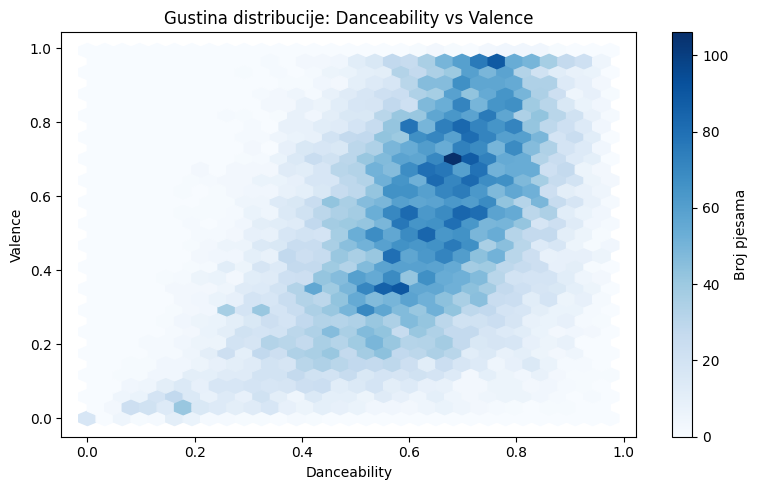

In [ ]:
plt.figure(figsize=(8, 5))
plt.hexbin(df['Danceability'], df['Valence'], gridsize=30, cmap='Blues')
plt.colorbar(label='Broj pjesama')
plt.xlabel('Danceability')
plt.ylabel('Valence')
plt.title('Gustina distribucije: Danceability vs Valence')
plt.tight_layout()
plt.show()

Ova vizualizacija prikazuje gustinu rasporeda pjesama u odnosu na njihove danceability i valence vrijednosti. Svaki heksagon pokazuje koliko se pjesama nalazi u tom dijelu grafika, pri čemu tamnije nijanse znače veću koncentraciju. Na osnovu rasporeda možemo vidjeti da većina pjesama koje su više plesne, ujedno imaju i viši valence, što dodatno potvrđuje rezultat testa koji je pokazao pozitivnu korelaciju između ove dvije osobine.

Ovaj tip grafa se nije pojavljivao na predavanjima, ali sam ga pronašla istražujući druge načine vizuelnog prikaza velikih skupova podataka, kako bi dodali malo raznolikosti u projekat. Činio mi se zanimljivim i korisnim kao dodatni alat koji pomaže da se lakše uoči veza između analiziranih varijabli.



---



# 10. **Model linearne regresije**

# *Model linearne regresije za predviđanje broja streamova pjesme* 🎙️

U ovom dijelu postavljamo model linearne regresije s ciljem da pokušamo predvidjeti broj streamova (numerička varijabla Stream u dataset-u) koje neka pjesma ostvaruje na Spotify platformi. Ova varijabla predstavlja ukupni broj slušanja određene pjesme i možemo je smatrati pokazateljem popularnosti u kontekstu modernog slušanja muzike na streaming platformama kao što je Spotify. Iako broj streamova zavisi od mnogo faktora koji nisu direktno sadržani u ovom datasetu (kao što su marketing, poznatost pjevača, vremenski trenutak objave pjesme i slično), fokusirali smo se na to kako muzičke osobine same pjesme mogu uticati na njen uspjeh na tržištu.

Za prediktorske varijable, odnosno varijable koje pretpostavljamo da utiču i da diktiraju uspjehu pjesme, odabrali smo varijable Danceability, Energy, Valence i Tempo. Svi ovi pokazatelji se odnose na tehničke ili emotivne karakteristike pjesme za koje pretpostavljamo da bi mogle imati uticaj na to koliko često će je ljudi slušati. Na primjer, Danceability označava koliko je pjesma pogodna za ples, pa se može pretpostaviti da će takve pjesme, koje često završavaju na plejlistama za partije, treniranje ili svakodnevno slušanje, ostvariti veći broj streamova. Slično tome, varijabla Energy u našem dataset-u označava koliko je pjesma intenzivna i dinamična, te je logična pretpostavka da energične pjesme obično privlače pažnju i imaju veću šansu da budu komercijalno uspješne. Varijabla Valence govori o emocionalnom tonu pjesme, što smo i prethodno naglašavali u drugim analizama, pri čemu više vrijednosti označavaju sretnije, optimističnije pjesme. Većina popularne muzike danas nosi upravo takav ton, pa smo odlučili da uključimo i tu varijablu. Na kraju, Tempo (izražen u BPM – beats per minute) govori o brzini pjesme, što takođe može igrati ulogu, jer određeni raspon tempa često dominira u popularnim žanrovima poput rap-a, pop-a, hip hop-a i sličnih.

Model ćemo postaviti kao višestruku linearnu regresiju, gdje će Stream biti zavisna (ciljna) varijabla, a sve navedene muzičke osobine poslužiće kao nezavisne (prediktorske) varijable. Ovim pristupom želimo da kvantitativno procijenimo da li postoji značajna veza između načina na koji pjesma "zvuči" i njenog stvarnog uspjeha u smislu broja slušanja. U nastavku ćemo prikazati rezultate modela, uključujući procijenjene koeficijente, R² vrijednost i p-vrijednosti za svaku varijablu, te ćemo pokušati protumačiti šta ti brojevi govore o uticaju pojedinih karakteristika pjesme na broj streamova.


In [ ]:
import pandas as pd
import statsmodels.api as sm

# Priprema podataka: biramo samo relevantne kolone i izbacujemo redove s NaN vrijednostima
df_reg = df[['Stream', 'Danceability', 'Energy', 'Valence', 'Tempo']].dropna()

# Definišemo X (nezavisne varijable) i y (zavisna varijabla)
X = df_reg[['Danceability', 'Energy', 'Valence', 'Tempo']]
y = df_reg['Stream']

# Dodajemo konstantu za intercept (presretanje)
X = sm.add_constant(X)

# Kreiramo i treniramo model
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Stream   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     52.81
Date:                Wed, 18 Jun 2025   Prob (F-statistic):           2.45e-44
Time:                        13:37:29   Log-Likelihood:            -4.1744e+05
No. Observations:               20140   AIC:                         8.349e+05
Df Residuals:                   20135   BIC:                         8.349e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         4.297e+07   1.03e+07      4.184   

# *Opis i objašnjenje koda*

U kodu smo prvo filtrirali odabrani set podataka tako da ostanu samo redovi koji imaju vrijednosti za sve izabrane varijable, kako bismo izbjegli probleme s nedostajućim podacima, kao što to radimo i pri drugim testovima i izradi grafova. Zatim smo odvojili zavisnu varijablu (y = Stream) od nezavisnih (X = Danceability, Energy, Valence, Tempo). Linearna regresija u statistici uključuje i tzv. konstantni član (intercept), koji se dodaje modelu pomoću funkcije add_constant, te on predstavlja očekivani broj streamova kada su sve ostale varijable jednake nuli.

Nakon toga smo koristili OLS (Ordinary Least Squares) model iz biblioteke statsmodels da “naučimo” regresijski model. OLS metoda pronalazi liniju (ili u ovom slučaju hiper-ravan) koja najbolje prati podatke tako što minimizira zbir kvadrata razlika između stvarnih i predviđenih vrijednosti. Na kraju, pomoću funkcije summary() dobijamo pregled rezultata: procijenjene koeficijente, p-vrijednosti, R² vrijednost i druge statističke informacije.

Ovaj postupak nam omogućava da kvantitativno procijenimo koliko i u kojem smjeru svaka od odabranih muzičkih osobina utiče na broj streamova, i da istovremeno vidimo koliko dobro cijeli model objašnjava varijaciju u podacima.

# *Tumačenje rezultata*

Rezultati linearnog regresionog modela pokazuju da je R² iznosio 0.010, što znači da svega 1% varijabilnosti u broju streamova može biti objašnjeno varijablama Danceability, Energy, Valence i Tempo. Iako je F-test bio statistički značajan (p < 0.0001), što znači da model kao cjelina ima određenu prediktivnu snagu, vrijednost R² je vrlo niska i sugeriše da su muzičke karakteristike same po sebi slab prediktor popularnosti pjesme na Spotify-u.

Gledajući pojedinačne varijable uočavamo zanimljive rezultate, koji možda i nisu u potpunosti u skladu s pretpostavkama s kojima smo krenuli u izradu modela.

Varijable Danceability i Energy imaju pozitivne i statistički značajne koeficijente (p < 0.001), što sugeriše da pjesme koje su plesnije i energičnije imaju tendenciju da imaju više streamova, što je u skladu s našim intuitivnim pretpostavkama. S druge strane, nezavisna varijabla Valence ima negativan i takođe značajan koeficijent, što je zanimljivo jer sugeriše da pjesme sa "sretnijim" emocionalnim tonom zapravo imaju nešto manje streamova, što nije intuitivno, ali može ukazivati na kompleksnost slušalačkih navika. Varijabla Tempo nije statistički značajna, njena p-vrijednost je svega 0.26, što znači da brzina pjesme ne utiče značajno na broj streamova u ovom modelu, što se opet ne slaže sa onim što bi mi inicijalno pretpostavili.

Ovaj model pokazuje da pojedine audio karakteristike pjesme, kao što su danceability i energy, mogu imati određeni uticaj na broj streamova, ali njihova ukupna prediktivna snaga je vrlo ograničena. Popularnost pjesme očigledno zavisi i od brojnih drugih faktora koji nisu uključeni u ovaj set podataka, koji možda više utiču na broj streamova. Ipak, model nam daje koristan uvid u to kako tehničke osobine pjesme mogu biti povezane s njenim komercijalnim uspjehom, čak i ako ne predstavljaju presudan faktor.

# *Vizualizacija*

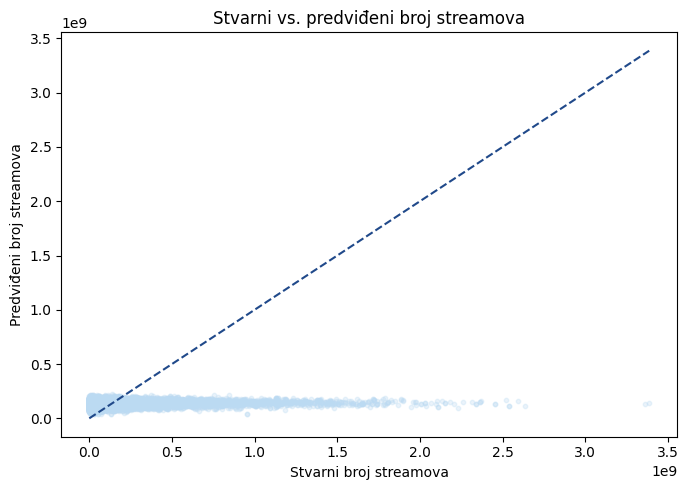

In [ ]:
import matplotlib.pyplot as plt

# Predviđene vrijednosti
y_pred = model.predict(X)

# Scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(y, y_pred, alpha=0.3, color='#BBDAF2', s=10)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='#20498A', linestyle='--')  # dijagonala
plt.xlabel('Stvarni broj streamova')
plt.ylabel('Predviđeni broj streamova')
plt.title('Stvarni vs. predviđeni broj streamova')
plt.tight_layout()
plt.show()


Na ovom grafu prikazan je odnos između stvarnih i predviđenih vrijednosti broja streamova za svaku pjesmu u modelu. Svaka tačka predstavlja jednu pjesmu (standardni scatter-plot), pri čemu je njena pozicija određena stvarnim brojem streamova na x-osi i predviđenim brojem na y-osi. Iscrtana dijagonalna linija predstavlja idealan slučaj gdje bi model savršeno pogodio svaki rezultat, dakle gdje su stvarna i predviđena vrijednost identične.

Kao što se vidi na grafu, većina tačaka je skoncentrisana u donjem lijevom dijelu, što znači da su i stvarne i predviđene vrijednosti u velikom broju slučajeva relativno male. Međutim, model je često potcijenio pjesme sa velikim brojem streamova što se vidi po tome što su mnoge tačke ispod dijagonale, pogotovo u desnom dijelu grafa. To potvrđuje prethodni rezultat regresije koji je pokazao vrlo nisku R² vrijednost, što znači da model ne uspijeva dobro objasniti varijaciju u broju streamova.

Ovaj graf je dodan kao vizuelni prikaz performansi modela, da se lakše uoči koliki je stvarni nesklad između onoga što model predviđa i onoga što se zaista dešava u podacima. Iako model prepoznaje opšti trend, jasno je da predviđanja nisu precizna, posebno kod najslušanijih pjesama.

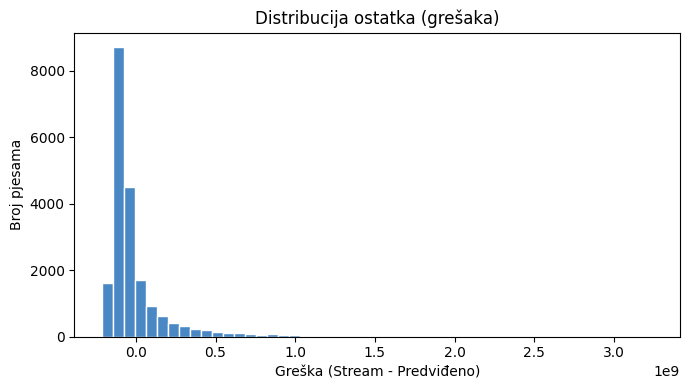

In [ ]:
residuals = y - y_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50, color='#4A88C5', edgecolor='white')
plt.title('Distribucija ostatka (grešaka)')
plt.xlabel('Greška (Stream - Predviđeno)')
plt.ylabel('Broj pjesama')
plt.tight_layout()
plt.show()


Na grafu je prikazana distribucija grešaka, odnosno razlika između stvarnog i predviđenog broja streamova za svaku pjesmu. Ove razlike nazivaju se reziduali i predstavljaju jedan od ključnih pokazatelja kvaliteta regresijskog modela. Idealno bi bilo da su ove greške ravnomjerno raspoređene oko nule i da nemaju izražene ekstremne vrijednosti.

Međutim, u ovom slučaju vidimo da većina pjesama ima male pozitivne greške, što znači da je model uglavnom potcijenio broj streamova. Ova vizualizacija nam pomaže da još jasnije uočimo ograničenja modela. Iako većina grešaka nije velika, postoji značajan broj pjesama kod kojih model ne uspijeva napraviti realnu procjenu.

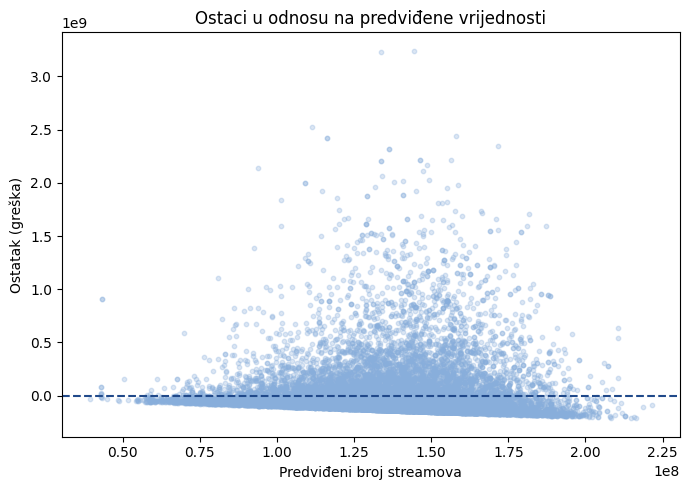

In [ ]:
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='#88AEDB', s=10)
plt.axhline(0, color='#20498A', linestyle='--')
plt.xlabel('Predviđeni broj streamova')
plt.ylabel('Ostatak (greška)')
plt.title('Ostaci u odnosu na predviđene vrijednosti')
plt.tight_layout()
plt.show()

Na ovom grafu prikazani su već spomenuti reziduali (greške modela) u odnosu na predviđene vrijednosti broja streamova. Svaka tačka predstavlja jednu pjesmu, a osa x pokazuje koliki broj streamova je model predvidio, dok osa y pokazuje razliku između stvarne i predviđene vrijednosti. Iscrtana horizontalna linija na nuli predstavlja situaciju kada je model pogodio tačnu vrijednost.

U idealnom slučaju, reziduali bi trebali biti ravnomjerno raspoređeni iznad i ispod nule, bez vidljivog obrasca što bi značilo da model pravi greške koje su nasumične i da je dobro postavljen. Međutim, ovdje se vidi da kako rastu predviđene vrijednosti, tako greške postaju sve veće i “raspršenije”.

Ova vizualizacija nam pomaže da bolje razumijemo gdje model ima problema, vidimo da model manje griješi kod manjih vrijednosti, ali kod popularnijih pjesama greške postaju znatno veće, što smo već i zaključili, te ovaj zaključak dodatno potvrđujemo.



---



# 11. **Zaključak**

Kroz ovaj rad, proveli smo Vas kroz detaljnu analizu Kaggle dataset-a vezanog za Spotify i Youtube, s ciljem da statističkim metodama razumijemo šta stoji iza popularnosti pjesama koje svakodnevno čujemo na radiju, u tržnom centru ili na socijalnim mrežama. Kroz deskriptivnu analizu i različite testove distribucije, identifikovali smo karakteristike numeričkih i kategorijskih varijabli, pri čemu su neke slijedile normalnu ili log-normalnu distribuciju, dok su druge pokazale odstupanja.

Primjenom χ² testa dobrote uklapanja, testova normalnosti (Shapiro–Wilk, Kolmogorov–Smirnov) i vizualizacijom putem QQ-plotova, potvrdili smo ili odbacili naše hipoteze. Također, izračunali smo intervale pouzdanosti za srednje vrijednosti i proporcije, te analizirali odnose između kategorijskih varijabli pomoću χ² testa nezavisnosti. Kroz postavljanje i testiranje većeg broja hipoteza koristeći metode opisane u poglavlju 10 u knjizi, dodatno smo proširili naš uvid u podatke, primjenjujući i parametarske i neparametarske pristupe.

Konačno, razvili smo regresioni model koji pokušava objasniti broj streamova pjesme na osnovu audio karakteristika. Iako je model imao ograničenu prediktivnu snagu (R² je oko 0.01), pokazao je zanimljive činjenice koje su nas iznenadile, naprimjer, plesnije i energičnije pjesme u prosjeku su imale više streamova, dok su one sa "sretnijim" tonom bile nešto manje slušane.

Ono što ovaj rad čini posebno zanimljivim jeste to što njegovu tematitku vidimo u svakodnevnom životu. Muzika je neizostavan dio našeg dana, slušamo je dok učimo, treniramo, radimo zadaću iz Vjerovatnoće i Statistike, guramo se s ljudima u javnom prevozu ili jednostavno pokušavamo preživjeti još jedan ispitni rok.
